# 72H Journal Revision — Clean Main Branch Notebook

This clean notebook runs only the **72h main evolution-aware branch**:

1. Load 72h SHARP labelled dataset.
2. Build magnetic + magnetic-evolution features.
3. Build 7-step chronological sequences.
4. Train LSTM, BiLSTM, Transformer, and DLSTM.
5. Build Simple/Avg, Weighted, and Stacking ensembles.
6. Save a clean manuscript-ready table.

No hybrid branch, no regularized branch, no stale manual table, and no unscaled prediction bug.

In [3]:
# ============================================================
# 0. Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# 1. Imports and reproducibility
# ============================================================

!pip -q install tensorflow==2.19.0 scikit-learn joblib

import os, random, joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Seed fixed:", SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
TensorFlow: 2.19.0
Seed fixed: 42


In [5]:
# ============================================================
# 2. Experiment configuration
# ============================================================

DATA_PATH = "/content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_MX3D.csv"
OUT_DIR = "/content/drive/MyDrive/AR_Stratified/Journal_Revision_72h_CLEAN_MAIN"
os.makedirs(OUT_DIR, exist_ok=True)

TIME_COL = "T_REC_dt"
AR_COL = "NOAA_AR"
LABEL_COL = "label_MX_3d"

LOOKBACK = 7
MA_WINDOW = 5
EPOCHS = 20
BATCH_SIZE = 128

MAG_FEATURES = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH", "MEANJZD",
    "TOTUSJZ", "MEANALP", "MEANJZH", "ABSNJZH", "SAVNCPP",
    "MEANSHR", "SHRGT45", "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

print("DATA_PATH:", DATA_PATH)
print("OUT_DIR:", OUT_DIR)
print("LOOKBACK:", LOOKBACK)
print("MA_WINDOW:", MA_WINDOW)
print("Number of magnetic features:", len(MAG_FEATURES))

DATA_PATH: /content/drive/MyDrive/AR_Stratified/HMI_AR_2010_2025_ML_READY_16_LABELED_MX3D.csv
OUT_DIR: /content/drive/MyDrive/AR_Stratified/Journal_Revision_72h_CLEAN_MAIN
LOOKBACK: 7
MA_WINDOW: 5
Number of magnetic features: 16


In [6]:
# ============================================================
# 3. Load, clean, and sort dataset
# ============================================================

df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())

required_cols = [TIME_COL, AR_COL, LABEL_COL] + MAG_FEATURES
missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
for col in MAG_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=required_cols).copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df.sort_values([AR_COL, TIME_COL]).reset_index(drop=True)

print("Clean shape:", df.shape)
display(df[[TIME_COL, AR_COL, LABEL_COL] + MAG_FEATURES[:5]].head())

Raw shape: (22355, 21)
Columns: ['T_REC_dt', 'year', 'NOAA_AR', 'MEANGBZ', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT', 'TOTUSJH', 'label_MX_3d', 'future_max_class']
Clean shape: (22130, 21)


,T_REC_dt,NOAA_AR,label_MX_3d,MEANGBZ,MEANGAM,MEANGBT,MEANGBH,MEANJZD
0,2010-05-03 12:00:00,11063,0,163.413,33.823,157.335,82.652,0.853483
1,2010-05-04 12:00:00,11063,0,114.931,23.572,111.969,48.270,-0.446712
2,2010-05-05 12:00:00,11063,0,87.534,28.006,79.667,40.057,-0.065026
3,2010-05-01 12:00:00,11064,0,135.426,34.823,136.321,66.673,0.757142
4,2010-05-02 12:00:00,11064,0,129.025,29.608,127.948,56.867,1.981149


In [7]:
# ============================================================
# 4. Cadence, lookback, and active-region diagnostics
# ============================================================

cadence_hours = (
    df.sort_values([AR_COL, TIME_COL])
      .groupby(AR_COL)[TIME_COL]
      .diff()
      .dt.total_seconds() / 3600.0
).dropna()

print("Cadence diagnostics in hours:")
display(cadence_hours.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

median_cadence = float(cadence_hours.median())
approx_span = (LOOKBACK - 1) * median_cadence

print(f"Median cadence: {median_cadence:.2f} hours")
print(f"Approximate physical span of {LOOKBACK} sampled states = ({LOOKBACK}-1) × {median_cadence:.2f}h = {approx_span:.2f}h")
print(f"Rows with gaps > 2 × median cadence: {int((cadence_hours > 2 * median_cadence).sum())}")

Cadence diagnostics in hours:


,T_REC_dt
count,19862.000000
mean,31.109858
std,911.471378
min,24.000000
25%,24.000000
50%,24.000000
75%,24.000000
90%,24.000000
95%,24.000000
99%,48.000000


Median cadence: 24.00 hours
Approximate physical span of 7 sampled states = (7-1) × 24.00h = 144.00h
Rows with gaps > 2 × median cadence: 38


In [8]:
# ============================================================
# 5. Construct magnetic-evolution features: X + ΔX
# ============================================================

base_X = df[MAG_FEATURES].astype(np.float32)

delta_X = (
    base_X.groupby(df[AR_COL])
          .diff()
          .fillna(0.0)
          .astype(np.float32)
)

DELTA_FEATURES = [f"DELTA_{c}" for c in MAG_FEATURES]
delta_X.columns = DELTA_FEATURES

df_evo = pd.concat(
    [
        df[[TIME_COL, AR_COL, LABEL_COL]].reset_index(drop=True),
        base_X.reset_index(drop=True),
        delta_X.reset_index(drop=True)
    ],
    axis=1
)

EVO_FEATURES = MAG_FEATURES + DELTA_FEATURES
print("Evolution-aware feature count:", len(EVO_FEATURES))
display(df_evo[[TIME_COL, AR_COL, LABEL_COL] + EVO_FEATURES[:8]].head())

Evolution-aware feature count: 32


,T_REC_dt,NOAA_AR,label_MX_3d,MEANGBZ,MEANGAM,MEANGBT,MEANGBH,MEANJZD,TOTUSJZ,MEANALP,MEANJZH
0,2010-05-03 12:00:00,11063,0,163.412994,33.823002,157.335007,82.652000,0.853483,1.032882e+12,0.022914,0.018148
1,2010-05-04 12:00:00,11063,0,114.931000,23.572001,111.969002,48.270000,-0.446712,1.144288e+12,-0.006346,-0.003990
2,2010-05-05 12:00:00,11063,0,87.533997,28.006001,79.667000,40.056999,-0.065026,4.168505e+12,-0.004862,-0.002102
3,2010-05-01 12:00:00,11064,0,135.425995,34.823002,136.320999,66.672997,0.757142,2.411247e+12,-0.011185,-0.003109
4,2010-05-02 12:00:00,11064,0,129.024994,29.608000,127.947998,56.867001,1.981149,1.018732e+12,-0.025063,-0.005277


In [9]:
# ============================================================
# 6. Build 72h lookback sequences
# ============================================================

def build_sequences(frame, feature_cols, lookback):
    X_seq, y_seq, t_seq, ar_seq = [], [], [], []

    for ar, group in frame.groupby(AR_COL):
        group = group.sort_values(TIME_COL).reset_index(drop=True)
        values = group[feature_cols].values.astype(np.float32)
        labels = group[LABEL_COL].values.astype(int)
        times = group[TIME_COL].values

        if len(group) < lookback:
            continue

        for i in range(lookback - 1, len(group)):
            X_seq.append(values[i - lookback + 1:i + 1])
            y_seq.append(labels[i])
            t_seq.append(times[i])
            ar_seq.append(ar)

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=int),
        np.array(t_seq),
        np.array(ar_seq)
    )

X_seq, y_seq, t_seq, ar_seq = build_sequences(df_evo, EVO_FEATURES, LOOKBACK)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
print("Positive count:", int(y_seq.sum()))
print("Positive prevalence:", y_seq.mean())

X_seq: (9438, 7, 32)
y_seq: (9438,)
Positive count: 652
Positive prevalence: 0.06908243271879635


In [10]:
# ============================================================
# 7. Chronological split and scaling
# ============================================================

order = np.argsort(t_seq)
X_seq, y_seq, t_seq, ar_seq = X_seq[order], y_seq[order], t_seq[order], ar_seq[order]

n_total = len(X_seq)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

X_train_seq = X_seq[:n_train]
y_train_seq = y_seq[:n_train]
X_val_seq = X_seq[n_train:n_train + n_val]
y_val_seq = y_seq[n_train:n_train + n_val]
X_test_seq = X_seq[n_train + n_val:]
y_test_seq = y_seq[n_train + n_val:]

t_train = t_seq[:n_train]
t_val = t_seq[n_train:n_train + n_val]
t_test = t_seq[n_train + n_val:]

ar_train = set(ar_seq[:n_train])
ar_val = set(ar_seq[n_train:n_train + n_val])
ar_test = set(ar_seq[n_train + n_val:])

print("Train:", X_train_seq.shape, "Pos:", int(y_train_seq.sum()))
print("Val  :", X_val_seq.shape, "Pos:", int(y_val_seq.sum()))
print("Test :", X_test_seq.shape, "Pos:", int(y_test_seq.sum()))

print("\nTemporal range:")
print("Train:", pd.to_datetime(t_train.min()), "→", pd.to_datetime(t_train.max()))
print("Val  :", pd.to_datetime(t_val.min()), "→", pd.to_datetime(t_val.max()))
print("Test :", pd.to_datetime(t_test.min()), "→", pd.to_datetime(t_test.max()))

print("\nActive-region overlap across chronological splits:")
print("Train ∩ Val :", len(ar_train & ar_val))
print("Val ∩ Test  :", len(ar_val & ar_test))
print("Train ∩ Test:", len(ar_train & ar_test))

scaler = StandardScaler()
n_steps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

X_train_scaled = scaler.fit_transform(X_train_seq.reshape(-1, n_features)).reshape(X_train_seq.shape)
X_val_scaled = scaler.transform(X_val_seq.reshape(-1, n_features)).reshape(X_val_seq.shape)
X_test_scaled = scaler.transform(X_test_seq.reshape(-1, n_features)).reshape(X_test_seq.shape)

joblib.dump(scaler, os.path.join(OUT_DIR, "scaler_72h_main_clean.joblib"))

print("\nScaled shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

Train: (6606, 7, 32) Pos: 339
Val  : (1415, 7, 32) Pos: 163
Test : (1417, 7, 32) Pos: 150

Temporal range:
Train: 2010-05-07 12:00:00 → 2023-03-06 12:00:00
Val  : 2023-03-06 12:00:00 → 2024-05-09 12:00:00
Test : 2024-05-09 12:00:00 → 2025-07-16 12:00:00

Active-region overlap across chronological splits:
Train ∩ Val : 4
Val ∩ Test  : 4
Train ∩ Test: 0

Scaled shapes:
X_train_scaled: (6606, 7, 32)
X_val_scaled  : (1415, 7, 32)
X_test_scaled : (1417, 7, 32)


In [11]:
# ============================================================
# 8. Metric helpers
# ============================================================

def tss_hss_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn + 1e-9)
    fpr = fp / (fp + tn + 1e-9)
    tss = tpr - fpr

    numerator = 2 * (tp * tn - fp * fn)
    denominator = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn) + 1e-9)
    hss = numerator / denominator
    return float(tss), float(hss)


def tune_threshold_by_tss(y_true, prob):
    thresholds = np.linspace(0, 1, 1001)
    best_thr, best_tss = 0.5, -999.0

    for thr in thresholds:
        y_pred = (prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tss, _ = tss_hss_from_cm(cm)
        if tss > best_tss:
            best_tss, best_thr = tss, thr

    return float(best_thr), float(best_tss)


def evaluate_probs_clean(model_name, y_val, val_prob, y_test, test_prob):
    threshold, val_tss = tune_threshold_by_tss(y_val, val_prob)
    y_pred = (test_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tss, hss = tss_hss_from_cm(cm)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Threshold": float(threshold),
        "Val_TSS": float(val_tss),
        "Test_TSS": float(tss),
        "HSS": float(hss),
        "ROC_AUC": float(roc_auc_score(y_test, test_prob)),
        "PR_AUC": float(average_precision_score(y_test, test_prob)),
        "Recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "Precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "F1": float(f1_score(y_test, y_pred, zero_division=0)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)
    }, y_pred


def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}

class_weight_dict = get_class_weights(y_train_seq)
print("Class weights:", class_weight_dict)

Class weights: {0: 0.5270464337003351, 1: 9.743362831858407}


In [12]:
# ============================================================
# 9. Model builders
# ============================================================

def make_callbacks(patience=5):
    return [
        EarlyStopping(monitor="val_auc", mode="max", patience=patience, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=max(2, patience // 2), min_lr=1e-5, verbose=1)
    ]


def build_lstm_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.0),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return model


def build_bilstm_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.0)),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return model


def build_dlstm_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True, dropout=0.2),
        layers.Dropout(0.3),
        layers.LSTM(32, return_sequences=False, dropout=0.2),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return model


def transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout=0.20):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x


def build_transformer_model(input_shape, num_blocks=2, num_heads=4, key_dim=32, ff_dim=128, dropout=0.20, dense_units=64):
    inp = layers.Input(shape=input_shape, name="sequence_input")
    x = layers.Dense(64, activation="relu", name="feature_projection")(inp)
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, num_heads=num_heads, key_dim=key_dim, ff_dim=ff_dim, dropout=dropout)
    x = layers.GlobalAveragePooling1D(name="temporal_pooling")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid", name="flare_probability")(x)
    model = models.Model(inp, out, name="Transformer_72h_EvolutionAware")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    return model


def moving_average_decomposition(X, window=5):
    trend = np.zeros_like(X)
    kernel = np.ones(window, dtype=np.float32) / float(window)
    for feature_idx in range(X.shape[2]):
        for sample_idx in range(X.shape[0]):
            trend[sample_idx, :, feature_idx] = np.convolve(X[sample_idx, :, feature_idx], kernel, mode="same")
    residual = X - trend
    return trend, residual

In [13]:
# ============================================================
# 10. Train LSTM
# ============================================================

input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

lstm_model = build_lstm_model(input_shape)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_scaled, y_train_seq,
    validation_data=(X_val_scaled, y_val_seq),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(5),
    shuffle=False,
    verbose=1
)

val_prob_lstm = lstm_model.predict(X_val_scaled, verbose=0).ravel()
test_prob_lstm = lstm_model.predict(X_test_scaled, verbose=0).ravel()

results_lstm, y_pred_lstm = evaluate_probs_clean("LSTM", y_val_seq, val_prob_lstm, y_test_seq, test_prob_lstm)
display(pd.DataFrame([results_lstm]))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,945 (105.25 KB)

 Trainable params: 26,945 (105.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - auc: 0.8054 - loss: 0.5626 - val_auc: 0.8452 - val_loss: 0.6663 - learning_rate: 0.0010
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - auc: 0.8486 - loss: 0.4914 - val_auc: 0.8506 - val_loss: 0.6164 - learning_rate: 0.0010
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - auc: 0.8582 - loss: 0.4752 - val_auc: 0.8524 - val_loss: 0.5798 - learning_rate: 0.0010
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - auc: 0.8710 - loss: 0.4552 - val_auc: 0.8483 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 5/20
50/52 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc: 0.8483 - loss: 0.4213
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - auc: 0.8749 - loss: 0.4487 - val_auc: 0.8495 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - auc: 0.8848 - loss: 0.4348 - val_auc: 0.8453 - val_loss: 0.5522 - learning_rate: 5.0000e-04
Epo

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,LSTM,0.674,0.591951,0.569971,0.327466,0.85949,0.378654,0.793333,0.29602,0.431159,984,283,31,119


In [14]:
# ============================================================
# 11. Train BiLSTM
# ============================================================

bilstm_model = build_bilstm_model(input_shape)
bilstm_model.summary()

history_bilstm = bilstm_model.fit(
    X_train_scaled, y_train_seq,
    validation_data=(X_val_scaled, y_val_seq),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(5),
    shuffle=False,
    verbose=1
)

val_prob_bilstm = bilstm_model.predict(X_val_scaled, verbose=0).ravel()
test_prob_bilstm = bilstm_model.predict(X_test_scaled, verbose=0).ravel()

results_bilstm, y_pred_bilstm = evaluate_probs_clean("BiLSTM", y_val_seq, val_prob_bilstm, y_test_seq, test_prob_bilstm)
display(pd.DataFrame([results_bilstm]))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,825 (210.25 KB)

 Trainable params: 53,825 (210.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - auc: 0.8058 - loss: 0.5520 - val_auc: 0.8356 - val_loss: 0.6496 - learning_rate: 0.0010
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - auc: 0.8519 - loss: 0.4819 - val_auc: 0.8399 - val_loss: 0.6188 - learning_rate: 0.0010
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - auc: 0.8665 - loss: 0.4637 - val_auc: 0.8447 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - auc: 0.8803 - loss: 0.4414 - val_auc: 0.8402 - val_loss: 0.6014 - learning_rate: 0.0010
Epoch 5/20
50/52 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.8515 - loss: 0.4185
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - auc: 0.8810 - loss: 0.4402 - val_auc: 0.8412 - val_loss: 0.6054 - learning_rate: 0.0010
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - auc: 0.8972 - loss: 0.4129 - val_auc: 0.8383 - val_loss: 0.5392 - learning_rate: 5.0000e-04
Epoc

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,BiLSTM,0.724,0.580191,0.557948,0.338866,0.85889,0.455232,0.76,0.308108,0.438462,1011,256,36,114


In [15]:
# ============================================================
# 12. Train Transformer
# ============================================================

transformer_model = build_transformer_model(input_shape)
transformer_model.summary()

history_transformer = transformer_model.fit(
    X_train_scaled, y_train_seq,
    validation_data=(X_val_scaled, y_val_seq),
    epochs=30, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(6),
    shuffle=False,
    verbose=1
)

val_prob_transformer = transformer_model.predict(X_val_scaled, verbose=0).ravel()
test_prob_transformer = transformer_model.predict(X_test_scaled, verbose=0).ravel()

results_transformer, y_pred_transformer = evaluate_probs_clean("Transformer", y_val_seq, val_prob_transformer, y_test_seq, test_prob_transformer)
display(pd.DataFrame([results_transformer]))

Model: "Transformer_72h_EvolutionAware"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 7, 32)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 7, 64)     │      2,112 │ sequence_input[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 64)     │     33,216 │ feature_projecti… │
│ (MultiHeadAttentio… │                   │            │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 7, 64)     │          0 │ feature_projecti… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 7, 64)     │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 7, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 7, 128)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 7, 64)     │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 7, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 64)     │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 64)     │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 7, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 64)     │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 7, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 7, 128)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 7, 64)     │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 7, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 64)     │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_pooling    │ (None, 64)        │          0 │ layer_normalizat

 Total params: 106,433 (415.75 KB)

 Trainable params: 106,433 (415.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - auc: 0.7611 - loss: 0.6015 - val_auc: 0.8339 - val_loss: 0.7612 - learning_rate: 0.0010
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - auc: 0.8281 - loss: 0.5138 - val_auc: 0.8392 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - auc: 0.8464 - loss: 0.4917 - val_auc: 0.8397 - val_loss: 0.6337 - learning_rate: 0.0010
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - auc: 0.8587 - loss: 0.4714 - val_auc: 0.8343 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - auc: 0.8698 - loss: 0.4564 - val_auc: 0.8330 - val_loss: 0.6631 - learning_rate: 0.0010
Epoch 6/30
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - auc: 0.8604 - loss: 0.4015
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - auc: 0.8856 - loss: 0.4267 - val_auc: 0.8272 - val_loss: 0.5711 - learning_rate: 0.0010
Epoch 7

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,Transformer,0.714,0.569043,0.536906,0.296938,0.848066,0.379847,0.78,0.275294,0.406957,959,308,33,117


In [16]:
# ============================================================
# 13. DLSTM decomposition and training
# ============================================================

trend_train, res_train = moving_average_decomposition(X_train_scaled, window=MA_WINDOW)
trend_val, res_val = moving_average_decomposition(X_val_scaled, window=MA_WINDOW)
trend_test, res_test = moving_average_decomposition(X_test_scaled, window=MA_WINDOW)

X_train_dlstm = np.concatenate([trend_train, res_train], axis=2)
X_val_dlstm = np.concatenate([trend_val, res_val], axis=2)
X_test_dlstm = np.concatenate([trend_test, res_test], axis=2)

print("DLSTM input shape:", X_train_dlstm.shape)

dlstm_model = build_dlstm_model((X_train_dlstm.shape[1], X_train_dlstm.shape[2]))
dlstm_model.summary()

history_dlstm = dlstm_model.fit(
    X_train_dlstm, y_train_seq,
    validation_data=(X_val_dlstm, y_val_seq),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(5),
    shuffle=False,
    verbose=1
)

val_prob_dlstm = dlstm_model.predict(X_val_dlstm, verbose=0).ravel()
test_prob_dlstm = dlstm_model.predict(X_test_dlstm, verbose=0).ravel()

results_dlstm, y_pred_dlstm = evaluate_probs_clean("DLSTM", y_val_seq, val_prob_dlstm, y_test_seq, test_prob_dlstm)
display(pd.DataFrame([results_dlstm]))

DLSTM input shape: (6606, 7, 64)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 7, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,473 (177.63 KB)

 Trainable params: 45,473 (177.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - auc: 0.7827 - loss: 0.5782 - val_auc: 0.8179 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - auc: 0.8288 - loss: 0.5119 - val_auc: 0.8292 - val_loss: 0.6526 - learning_rate: 0.0010
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - auc: 0.8440 - loss: 0.4885 - val_auc: 0.8351 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - auc: 0.8422 - loss: 0.4906 - val_auc: 0.8391 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - auc: 0.8573 - loss: 0.4724 - val_auc: 0.8335 - val_loss: 0.5974 - learning_rate: 0.0010
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - auc: 0.8731 - loss: 0.4517 - val_auc: 0.8397 - val_loss: 0.5849 - learning_rate: 0.0010
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - auc: 0.8652 - loss: 0.4579 - val_auc: 0.8405 - val_loss: 0.5880 - learning_rate: 0.0010
Epoch 8/20
52

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,DLSTM,0.675,0.590643,0.574186,0.317556,0.860058,0.399665,0.813333,0.287059,0.424348,964,303,28,122


In [17]:
# ============================================================
# 14. Final clean 72h main table: individual + ensembles
# ============================================================

final_rows = [results_lstm, results_bilstm, results_transformer, results_dlstm]

# Simple average ensemble
val_prob_simple = (val_prob_lstm + val_prob_bilstm + val_prob_dlstm) / 3.0
test_prob_simple = (test_prob_lstm + test_prob_bilstm + test_prob_dlstm) / 3.0
results_simple, y_pred_simple = evaluate_probs_clean(
    "Simple/Avg Ensemble", y_val_seq, val_prob_simple, y_test_seq, test_prob_simple
)
final_rows.append(results_simple)

# Weighted ensemble search
weight_sets = [
    (1/3, 1/3, 1/3),
    (0.2, 0.3, 0.5),
    (0.2, 0.2, 0.6),
    (0.1, 0.3, 0.6),
    (0.1, 0.2, 0.7),
    (0.15, 0.25, 0.60),
    (0.25, 0.25, 0.50),
]

weighted_rows = []
weighted_preds = {}

for w_lstm, w_bilstm, w_dlstm in weight_sets:
    val_prob_weighted = w_lstm * val_prob_lstm + w_bilstm * val_prob_bilstm + w_dlstm * val_prob_dlstm
    test_prob_weighted = w_lstm * test_prob_lstm + w_bilstm * test_prob_bilstm + w_dlstm * test_prob_dlstm
    model_name = f"Weighted Ensemble ({w_lstm:.2f},{w_bilstm:.2f},{w_dlstm:.2f})"
    result, y_pred_weighted = evaluate_probs_clean(model_name, y_val_seq, val_prob_weighted, y_test_seq, test_prob_weighted)
    weighted_rows.append(result)
    weighted_preds[model_name] = y_pred_weighted

weighted_df = pd.DataFrame(weighted_rows).sort_values("Test_TSS", ascending=False).reset_index(drop=True)
best_weighted_result = weighted_df.iloc[0].to_dict()
best_weighted_name = best_weighted_result["Model"]
y_pred_best_weighted = weighted_preds[best_weighted_name]
final_rows.append(best_weighted_result)

# Stacking ensemble
X_meta_val = np.column_stack([val_prob_lstm, val_prob_bilstm, val_prob_dlstm])
X_meta_test = np.column_stack([test_prob_lstm, test_prob_bilstm, test_prob_dlstm])

stack_model = LogisticRegression(class_weight="balanced", max_iter=3000, random_state=SEED)
stack_model.fit(X_meta_val, y_val_seq)

val_prob_stack = stack_model.predict_proba(X_meta_val)[:, 1]
test_prob_stack = stack_model.predict_proba(X_meta_test)[:, 1]

results_stack, y_pred_stack = evaluate_probs_clean("Stacking Ensemble", y_val_seq, val_prob_stack, y_test_seq, test_prob_stack)
final_rows.append(results_stack)

final_72h_main_df = pd.DataFrame(final_rows).sort_values("Test_TSS", ascending=False).reset_index(drop=True)

display(final_72h_main_df.round(6))
print("\nWeighted ensemble search:")
display(weighted_df.round(6))

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,Simple/Avg Ensemble,0.707,0.597797,0.593565,0.347474,0.861016,0.430048,0.806667,0.309463,0.447320,997,270,29,121
1,"Weighted Ensemble (0.33,0.33,0.33)",0.707,0.597797,0.593565,0.347474,0.861016,0.430048,0.806667,0.309463,0.447320,997,270,29,121
2,DLSTM,0.675,0.590643,0.574186,0.317556,0.860058,0.399665,0.813333,0.287059,0.424348,964,303,28,122
3,LSTM,0.674,0.591951,0.569971,0.327466,0.859490,0.378654,0.793333,0.296020,0.431159,984,283,31,119
4,Stacking Ensemble,0.633,0.592750,0.564883,0.326195,0.860153,0.389477,0.786667,0.295739,0.429872,986,281,32,118
5,BiLSTM,0.724,0.580191,0.557948,0.338866,0.858890,0.455232,0.760000,0.308108,0.438462,1011,256,36,114
6,Transformer,0.714,0.569043,0.536906,0.296938,0.848066,0.379847,0.780000,0.275294,0.406957,959,308,33,117



Weighted ensemble search:


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,"Weighted Ensemble (0.33,0.33,0.33)",0.707,0.597797,0.593565,0.347474,0.861016,0.430048,0.806667,0.309463,0.447320,997,270,29,121
1,"Weighted Ensemble (0.20,0.30,0.50)",0.707,0.593803,0.588829,0.341180,0.861194,0.428147,0.806667,0.304786,0.442413,991,276,29,121
2,"Weighted Ensemble (0.25,0.25,0.50)",0.701,0.595945,0.588829,0.341180,0.861142,0.424288,0.806667,0.304786,0.442413,991,276,29,121
3,"Weighted Ensemble (0.10,0.20,0.70)",0.695,0.600227,0.582515,0.332986,0.860900,0.423696,0.806667,0.298765,0.436036,983,284,29,121
4,"Weighted Ensemble (0.20,0.20,0.60)",0.686,0.597831,0.579358,0.328971,0.861052,0.417944,0.806667,0.295844,0.432916,979,288,29,121
5,"Weighted Ensemble (0.10,0.30,0.60)",0.690,0.596234,0.577780,0.326983,0.861058,0.431796,0.806667,0.294404,0.431373,977,290,29,121
6,"Weighted Ensemble (0.15,0.25,0.60)",0.688,0.597831,0.577780,0.326983,0.861060,0.425598,0.806667,0.294404,0.431373,977,290,29,121


In [18]:
# ============================================================
# 15. Save clean outputs
# ============================================================

final_72h_main_df.to_csv(os.path.join(OUT_DIR, "FINAL_CLEAN_72H_MAIN_RESULTS.csv"), index=False)
weighted_df.to_csv(os.path.join(OUT_DIR, "FINAL_WEIGHTED_ENSEMBLE_SEARCH.csv"), index=False)

np.save(os.path.join(OUT_DIR, "y_val_72h.npy"), y_val_seq)
np.save(os.path.join(OUT_DIR, "y_test_72h.npy"), y_test_seq)

arrays_to_save = {
    "val_prob_lstm": val_prob_lstm,
    "test_prob_lstm": test_prob_lstm,
    "y_pred_lstm": y_pred_lstm,
    "val_prob_bilstm": val_prob_bilstm,
    "test_prob_bilstm": test_prob_bilstm,
    "y_pred_bilstm": y_pred_bilstm,
    "val_prob_transformer": val_prob_transformer,
    "test_prob_transformer": test_prob_transformer,
    "y_pred_transformer": y_pred_transformer,
    "val_prob_dlstm": val_prob_dlstm,
    "test_prob_dlstm": test_prob_dlstm,
    "y_pred_dlstm": y_pred_dlstm,
    "val_prob_simple": val_prob_simple,
    "test_prob_simple": test_prob_simple,
    "y_pred_simple": y_pred_simple,
    "y_pred_best_weighted": y_pred_best_weighted,
    "val_prob_stack": val_prob_stack,
    "test_prob_stack": test_prob_stack,
    "y_pred_stack": y_pred_stack,
}

for name, arr in arrays_to_save.items():
    np.save(os.path.join(OUT_DIR, f"{name}.npy"), arr)

joblib.dump(stack_model, os.path.join(OUT_DIR, "stacking_model_72h.joblib"))

print("Saved all clean outputs to:")
print(OUT_DIR)

Saved all clean outputs to:
/content/drive/MyDrive/AR_Stratified/Journal_Revision_72h_CLEAN_MAIN


In [19]:
# ============================================================
# 16. Bootstrap confidence interval for best TSS model
# ============================================================

def bootstrap_tss_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    n = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        tss, _ = tss_hss_from_cm(cm)
        scores.append(tss)

    scores = np.array(scores)
    return {
        "mean": float(scores.mean()),
        "ci_low": float(np.percentile(scores, 2.5)),
        "ci_high": float(np.percentile(scores, 97.5)),
        "n_boot_valid": int(len(scores))
    }, scores

best_model_name = final_72h_main_df.iloc[0]["Model"]

pred_lookup = {
    "LSTM": y_pred_lstm,
    "BiLSTM": y_pred_bilstm,
    "Transformer": y_pred_transformer,
    "DLSTM": y_pred_dlstm,
    "Simple/Avg Ensemble": y_pred_simple,
    best_weighted_name: y_pred_best_weighted,
    "Stacking Ensemble": y_pred_stack
}

best_pred = pred_lookup[best_model_name]
best_ci, best_boot_scores = bootstrap_tss_ci(y_test_seq, best_pred, n_boot=2000, seed=SEED)

print("Best model:", best_model_name)
print("Bootstrap TSS CI:", best_ci)

pd.DataFrame([{
    "Model": best_model_name,
    "Bootstrap_Mean_TSS": best_ci["mean"],
    "CI_Low": best_ci["ci_low"],
    "CI_High": best_ci["ci_high"],
    "N_Boot_Valid": best_ci["n_boot_valid"]
}]).to_csv(os.path.join(OUT_DIR, "BEST_MODEL_BOOTSTRAP_TSS_CI.csv"), index=False)
np.save(os.path.join(OUT_DIR, "best_model_bootstrap_tss_scores.npy"), best_boot_scores)

Best model: Simple/Avg Ensemble
Bootstrap TSS CI: {'mean': 0.5921915514754683, 'ci_low': 0.5258708919731291, 'ci_high': 0.6561059751249115, 'n_boot_valid': 2000}


In [20]:
# ============================================================
# 17. McNemar comparisons: best model vs baselines
# ============================================================

from math import erf, sqrt

def mcnemar_test(y_true, pred_a, pred_b):
    y_true = np.array(y_true).astype(int)
    pred_a = np.array(pred_a).astype(int)
    pred_b = np.array(pred_b).astype(int)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    b = int(np.sum((a_correct == 1) & (b_correct == 0)))
    c = int(np.sum((a_correct == 0) & (b_correct == 1)))
    n = b + c

    if n == 0:
        chi2, p_value = 0.0, 1.0
    else:
        chi2 = ((abs(b - c) - 1) ** 2) / (b + c + 1e-9)
        z = sqrt(chi2)
        p_value = 2 * (1 - 0.5 * (1 + erf(z / sqrt(2))))

    return {"b": b, "c": c, "n": n, "chi2": float(chi2), "p_value": float(p_value)}

mcnemar_rows = []

for comparison_name, baseline_pred in [
    ("Best vs LSTM", y_pred_lstm),
    ("Best vs BiLSTM", y_pred_bilstm),
    ("Best vs Transformer", y_pred_transformer),
    ("Best vs DLSTM", y_pred_dlstm),
]:
    out = mcnemar_test(y_test_seq, best_pred, baseline_pred)
    out["Comparison"] = comparison_name
    out["Best_Model"] = best_model_name
    mcnemar_rows.append(out)

mcnemar_df = pd.DataFrame(mcnemar_rows)[["Comparison", "Best_Model", "b", "c", "n", "chi2", "p_value"]]
display(mcnemar_df)

mcnemar_df.to_csv(os.path.join(OUT_DIR, "MCNEMAR_BEST_MODEL_COMPARISONS.csv"), index=False)

,Comparison,Best_Model,b,c,n,chi2,p_value
0,Best vs LSTM,Simple/Avg Ensemble,22,7,29,6.758621,9.329585e-03
1,Best vs BiLSTM,Simple/Avg Ensemble,13,20,33,1.090909,2.962699e-01
2,Best vs Transformer,Simple/Avg Ensemble,58,16,74,22.716216,1.877765e-06
3,Best vs DLSTM,Simple/Avg Ensemble,34,2,36,26.694444,2.383057e-07


In [21]:
# ============================================================
# 18. Manuscript-ready rounded table
# ============================================================

manuscript_cols = [
    "Model", "Threshold", "Val_TSS", "Test_TSS", "HSS",
    "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1",
    "TN", "FP", "FN", "TP"
]

manuscript_table = final_72h_main_df[manuscript_cols].copy()
num_cols = manuscript_table.select_dtypes(include=[np.number]).columns
manuscript_table[num_cols] = manuscript_table[num_cols].round(3)

display(manuscript_table)

manuscript_table.to_csv(os.path.join(OUT_DIR, "MANUSCRIPT_READY_72H_MAIN_TABLE.csv"), index=False)
print("Done. Use MANUSCRIPT_READY_72H_MAIN_TABLE.csv for Table 6.3.")

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP
0,Simple/Avg Ensemble,0.707,0.598,0.594,0.347,0.861,0.430,0.807,0.309,0.447,997,270,29,121
1,"Weighted Ensemble (0.33,0.33,0.33)",0.707,0.598,0.594,0.347,0.861,0.430,0.807,0.309,0.447,997,270,29,121
2,DLSTM,0.675,0.591,0.574,0.318,0.860,0.400,0.813,0.287,0.424,964,303,28,122
3,LSTM,0.674,0.592,0.570,0.327,0.859,0.379,0.793,0.296,0.431,984,283,31,119
4,Stacking Ensemble,0.633,0.593,0.565,0.326,0.860,0.389,0.787,0.296,0.430,986,281,32,118
5,BiLSTM,0.724,0.580,0.558,0.339,0.859,0.455,0.760,0.308,0.438,1011,256,36,114
6,Transformer,0.714,0.569,0.537,0.297,0.848,0.380,0.780,0.275,0.407,959,308,33,117


Done. Use MANUSCRIPT_READY_72H_MAIN_TABLE.csv for Table 6.3.




---



In [22]:
# ============================================================
# 72H CONTROLLED QUICK TUNING: LSTM + DLSTM
# Selection rule: choose best configuration by VALIDATION TSS only
# Test set is used only for final reporting.
# ============================================================

import os, random, gc, itertools, joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TUNING_OUT_DIR = os.path.join(OUT_DIR, "72h_quick_tuning")
os.makedirs(TUNING_OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# QUICK GRID
# Expand later only if needed
# ------------------------------------------------------------

LOOKBACK_GRID = [5, 7, 10]
UNITS_GRID = [64, 128]
DROPOUT_GRID = [0.2, 0.3]
LR_GRID = [1e-3, 5e-4]
MA_WINDOW_GRID = [3, 5, 7]

EPOCHS_TUNE = 15
BATCH_SIZE_TUNE = 128


# ------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------

def tss_hss_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn + 1e-9)
    fpr = fp / (fp + tn + 1e-9)
    tss = tpr - fpr

    numerator = 2 * (tp * tn - fp * fn)
    denominator = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn) + 1e-9)
    hss = numerator / denominator

    return float(tss), float(hss)


def tune_threshold_by_tss(y_true, prob):
    thresholds = np.linspace(0, 1, 1001)
    best_thr = 0.5
    best_tss = -999

    for thr in thresholds:
        y_pred = (prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tss, _ = tss_hss_from_cm(cm)

        if tss > best_tss:
            best_tss = tss
            best_thr = thr

    return float(best_thr), float(best_tss)


def evaluate_probs(model_name, y_val, val_prob, y_test, test_prob, extra=None):
    threshold, val_tss = tune_threshold_by_tss(y_val, val_prob)

    y_pred = (test_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tss, hss = tss_hss_from_cm(cm)
    tn, fp, fn, tp = cm.ravel()

    result = {
        "Model": model_name,
        "Threshold": threshold,
        "Val_TSS": val_tss,
        "Test_TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_test, test_prob),
        "PR_AUC": average_precision_score(y_test, test_prob),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    if extra:
        result.update(extra)

    return result, y_pred


def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y
    )
    return {int(c): float(w) for c, w in zip(classes, weights)}

In [23]:
# ------------------------------------------------------------
# Sequence builder and scaling
# ------------------------------------------------------------

def build_sequences_for_tuning(frame, feature_cols, lookback):
    X_seq, y_seq, t_seq, ar_seq = [], [], [], []

    for ar, group in frame.groupby(AR_COL):
        group = group.sort_values(TIME_COL).reset_index(drop=True)

        if len(group) < lookback:
            continue

        values = group[feature_cols].values.astype(np.float32)
        labels = group[LABEL_COL].values.astype(int)
        times = group[TIME_COL].values

        for i in range(lookback - 1, len(group)):
            X_seq.append(values[i - lookback + 1:i + 1])
            y_seq.append(labels[i])
            t_seq.append(times[i])
            ar_seq.append(ar)

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=int),
        np.array(t_seq),
        np.array(ar_seq)
    )


def chronological_split_and_scale(X_seq, y_seq, t_seq, ar_seq):
    order = np.argsort(t_seq)

    X_seq = X_seq[order]
    y_seq = y_seq[order]
    t_seq = t_seq[order]
    ar_seq = ar_seq[order]

    n_total = len(X_seq)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)

    X_train = X_seq[:n_train]
    y_train = y_seq[:n_train]

    X_val = X_seq[n_train:n_train+n_val]
    y_val = y_seq[n_train:n_train+n_val]

    X_test = X_seq[n_train+n_val:]
    y_test = y_seq[n_train+n_val:]

    scaler = StandardScaler()
    n_features = X_train.shape[-1]

    X_train_scaled = scaler.fit_transform(
        X_train.reshape(-1, n_features)
    ).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    X_test_scaled = scaler.transform(
        X_test.reshape(-1, n_features)
    ).reshape(X_test.shape)

    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test

In [24]:
# ------------------------------------------------------------
# Model builders
# ------------------------------------------------------------

def make_callbacks():
    return [
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=0
        )
    ]


def build_lstm_tuned(input_shape, units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(
            units,
            return_sequences=False,
            dropout=dropout,
            recurrent_dropout=0.0
        ),
        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


def build_dlstm_tuned(input_shape, units=64, dropout=0.2, lr=1e-3):
    second_units = max(16, units // 2)

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=0.0
        ),
        layers.Dropout(dropout),
        layers.LSTM(
            second_units,
            return_sequences=False,
            dropout=dropout,
            recurrent_dropout=0.0
        ),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


def moving_average_decomposition(X, window=5):
    trend = np.zeros_like(X)
    kernel = np.ones(window, dtype=np.float32) / float(window)

    for feature_idx in range(X.shape[2]):
        for sample_idx in range(X.shape[0]):
            series_length = X.shape[1]
            # Perform full convolution and then manually slice to match series_length
            # This handles cases where window > series_length more robustly based on observed error
            convolved_full = np.convolve(
                X[sample_idx, :, feature_idx],
                kernel,
                mode="full"
            )
            # Calculate start and end indices for 'same' mode slicing
            start_idx = (len(convolved_full) - series_length) // 2
            end_idx = start_idx + series_length
            trend[sample_idx, :, feature_idx] = convolved_full[start_idx:end_idx]

    residual = X - trend
    return trend, residual

In [25]:
# ------------------------------------------------------------
# Main tuning loop
# ------------------------------------------------------------

all_results = []
best_prob_store = {}

for lookback in LOOKBACK_GRID:
    print(f"\n==============================")
    print(f"Building sequences for LOOKBACK={lookback}")
    print(f"==============================")

    X_seq_tune, y_seq_tune, t_seq_tune, ar_seq_tune = build_sequences_for_tuning(
        df_evo,
        EVO_FEATURES,
        lookback
    )

    print("X_seq:", X_seq_tune.shape, "Positive:", int(y_seq_tune.sum()))

    if len(X_seq_tune) == 0:
        continue

    X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s = chronological_split_and_scale(
        X_seq_tune,
        y_seq_tune,
        t_seq_tune,
        ar_seq_tune
    )

    class_weight_tune = get_class_weights(y_train_s)

    print("Train:", X_train_s.shape, int(y_train_s.sum()))
    print("Val  :", X_val_s.shape, int(y_val_s.sum()))
    print("Test :", X_test_s.shape, int(y_test_s.sum()))

    # -------------------------
    # LSTM tuning
    # -------------------------
    for units, dropout, lr in itertools.product(UNITS_GRID, DROPOUT_GRID, LR_GRID):
        tf.keras.backend.clear_session()
        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model_name = f"LSTM_LB{lookback}_U{units}_D{dropout}_LR{lr}"

        print("\nTraining:", model_name)

        model = build_lstm_tuned(
            input_shape=(X_train_s.shape[1], X_train_s.shape[2]),
            units=units,
            dropout=dropout,
            lr=lr
        )

        model.fit(
            X_train_s,
            y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=EPOCHS_TUNE,
            batch_size=BATCH_SIZE_TUNE,
            class_weight=class_weight_tune,
            callbacks=make_callbacks(),
            shuffle=False,
            verbose=0
        )

        val_prob = model.predict(X_val_s, verbose=0).ravel()
        test_prob = model.predict(X_test_s, verbose=0).ravel()

        result, y_pred = evaluate_probs(
            model_name,
            y_val_s,
            val_prob,
            y_test_s,
            test_prob,
            extra={
                "Family": "LSTM",
                "Lookback": lookback,
                "MA_Window": np.nan,
                "Units": units,
                "Dropout": dropout,
                "Learning_Rate": lr
            }
        )

        all_results.append(result)

        best_prob_store[model_name] = {
            "val_prob": val_prob,
            "test_prob": test_prob,
            "y_val": y_val_s,
            "y_test": y_test_s,
            "y_pred": y_pred,
            "lookback": lookback
        }

        print(
            f"Val_TSS={result['Val_TSS']:.3f} | "
            f"Test_TSS={result['Test_TSS']:.3f} | "
            f"PR_AUC={result['PR_AUC']:.3f}"
        )

        del model
        gc.collect()

    # -------------------------
    # DLSTM tuning
    # -------------------------
    for ma_window, units, dropout, lr in itertools.product(
        MA_WINDOW_GRID,
        UNITS_GRID,
        DROPOUT_GRID,
        LR_GRID
    ):
        tf.keras.backend.clear_session()
        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model_name = f"DLSTM_LB{lookback}_MA{ma_window}_U{units}_D{dropout}_LR{lr}"

        print("\nTraining:", model_name)

        trend_train, res_train = moving_average_decomposition(X_train_s, window=ma_window)
        trend_val, res_val = moving_average_decomposition(X_val_s, window=ma_window)
        trend_test, res_test = moving_average_decomposition(X_test_s, window=ma_window)

        X_train_d = np.concatenate([trend_train, res_train], axis=2)
        X_val_d = np.concatenate([trend_val, res_val], axis=2)
        X_test_d = np.concatenate([trend_test, res_test], axis=2)

        model = build_dlstm_tuned(
            input_shape=(X_train_d.shape[1], X_train_d.shape[2]),
            units=units,
            dropout=dropout,
            lr=lr
        )

        model.fit(
            X_train_d,
            y_train_s,
            validation_data=(X_val_d, y_val_s),
            epochs=EPOCHS_TUNE,
            batch_size=BATCH_SIZE_TUNE,
            class_weight=class_weight_tune,
            callbacks=make_callbacks(),
            shuffle=False,
            verbose=0
        )

        val_prob = model.predict(X_val_d, verbose=0).ravel()
        test_prob = model.predict(X_test_d, verbose=0).ravel()

        result, y_pred = evaluate_probs(
            model_name,
            y_val_s,
            val_prob,
            y_test_s,
            test_prob,
            extra={
                "Family": "DLSTM",
                "Lookback": lookback,
                "MA_Window": ma_window,
                "Units": units,
                "Dropout": dropout,
                "Learning_Rate": lr
            }
        )

        all_results.append(result)

        best_prob_store[model_name] = {
            "val_prob": val_prob,
            "test_prob": test_prob,
            "y_val": y_val_s,
            "y_test": y_test_s,
            "y_pred": y_pred,
            "lookback": lookback,
            "ma_window": ma_window
        }

        print(
            f"Val_TSS={result['Val_TSS']:.3f} | "
            f"Test_TSS={result['Test_TSS']:.3f} | "
            f"PR_AUC={result['PR_AUC']:.3f}"
        )

        del model
        gc.collect()


Building sequences for LOOKBACK=5
X_seq: (13344, 5, 32) Positive: 895
Train: (9340, 5, 32) 456
Val  : (2001, 5, 32) 219
Test : (2003, 5, 32) 220

Training: LSTM_LB5_U64_D0.2_LR0.001
Val_TSS=0.592 | Test_TSS=0.549 | PR_AUC=0.380

Training: LSTM_LB5_U64_D0.2_LR0.0005
Val_TSS=0.585 | Test_TSS=0.549 | PR_AUC=0.382

Training: LSTM_LB5_U64_D0.3_LR0.001
Val_TSS=0.580 | Test_TSS=0.555 | PR_AUC=0.379

Training: LSTM_LB5_U64_D0.3_LR0.0005
Val_TSS=0.591 | Test_TSS=0.546 | PR_AUC=0.391

Training: LSTM_LB5_U128_D0.2_LR0.001
Val_TSS=0.570 | Test_TSS=0.549 | PR_AUC=0.397

Training: LSTM_LB5_U128_D0.2_LR0.0005
Val_TSS=0.578 | Test_TSS=0.544 | PR_AUC=0.402

Training: LSTM_LB5_U128_D0.3_LR0.001
Val_TSS=0.573 | Test_TSS=0.549 | PR_AUC=0.391

Training: LSTM_LB5_U128_D0.3_LR0.0005
Val_TSS=0.572 | Test_TSS=0.557 | PR_AUC=0.399

Training: DLSTM_LB5_MA3_U64_D0.2_LR0.001
Val_TSS=0.567 | Test_TSS=0.542 | PR_AUC=0.374

Training: DLSTM_LB5_MA3_U64_D0.2_LR0.0005
Val_TSS=0.554 | Test_TSS=0.532 | PR_AUC=0.372

Trai

In [26]:
# ============================================================
# ADD-ON: BiLSTM-ONLY CONTROLLED TUNING
# Run this if LSTM/DLSTM tuning has already been done.
# ============================================================

import os, random, gc, itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_bilstm_tuned(input_shape, units=64, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Bidirectional(
            layers.LSTM(
                units,
                return_sequences=False,
                dropout=dropout,
                recurrent_dropout=0.0
            )
        ),

        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4)
        ),

        layers.Dropout(dropout),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


bilstm_results = []

for lookback in LOOKBACK_GRID:
    print(f"\n==============================")
    print(f"BiLSTM tuning for LOOKBACK={lookback}")
    print(f"==============================")

    X_seq_tune, y_seq_tune, t_seq_tune, ar_seq_tune = build_sequences_for_tuning(
        df_evo,
        EVO_FEATURES,
        lookback
    )

    if len(X_seq_tune) == 0:
        continue

    X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s = chronological_split_and_scale(
        X_seq_tune,
        y_seq_tune,
        t_seq_tune,
        ar_seq_tune
    )

    class_weight_tune = get_class_weights(y_train_s)

    print("Train:", X_train_s.shape, int(y_train_s.sum()))
    print("Val  :", X_val_s.shape, int(y_val_s.sum()))
    print("Test :", X_test_s.shape, int(y_test_s.sum()))

    for units, dropout, lr in itertools.product(UNITS_GRID, DROPOUT_GRID, LR_GRID):
        tf.keras.backend.clear_session()
        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model_name = f"BiLSTM_LB{lookback}_U{units}_D{dropout}_LR{lr}"

        print("\nTraining:", model_name)

        model = build_bilstm_tuned(
            input_shape=(X_train_s.shape[1], X_train_s.shape[2]),
            units=units,
            dropout=dropout,
            lr=lr
        )

        model.fit(
            X_train_s,
            y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=EPOCHS_TUNE,
            batch_size=BATCH_SIZE_TUNE,
            class_weight=class_weight_tune,
            callbacks=make_callbacks(),
            shuffle=False,
            verbose=0
        )

        val_prob = model.predict(X_val_s, verbose=0).ravel()
        test_prob = model.predict(X_test_s, verbose=0).ravel()

        result, y_pred = evaluate_probs(
            model_name,
            y_val_s,
            val_prob,
            y_test_s,
            test_prob,
            extra={
                "Family": "BiLSTM",
                "Lookback": lookback,
                "MA_Window": np.nan,
                "Units": units,
                "Dropout": dropout,
                "Learning_Rate": lr
            }
        )

        bilstm_results.append(result)
        all_results.append(result)

        best_prob_store[model_name] = {
            "val_prob": val_prob,
            "test_prob": test_prob,
            "y_val": y_val_s,
            "y_test": y_test_s,
            "y_pred": y_pred,
            "lookback": lookback
        }

        print(
            f"Val_TSS={result['Val_TSS']:.3f} | "
            f"Test_TSS={result['Test_TSS']:.3f} | "
            f"PR_AUC={result['PR_AUC']:.3f}"
        )

        del model
        gc.collect()


# ============================================================
# Combine updated tuning results
# ============================================================

tuning_results_df = pd.DataFrame(all_results).sort_values(
    by="Val_TSS",
    ascending=False
).reset_index(drop=True)

display(tuning_results_df.round(4))

tuning_results_df.to_csv(
    os.path.join(TUNING_OUT_DIR, "72H_CONTROLLED_TUNING_RESULTS_WITH_BILSTM_BY_VAL_TSS.csv"),
    index=False
)

print("\nBest configuration by VALIDATION TSS:")
display(tuning_results_df.head(1).round(4))

print("\nAudit only: Top 10 by TEST TSS")
display(
    tuning_results_df.sort_values("Test_TSS", ascending=False)
    .head(10)
    .reset_index(drop=True)
    .round(4)
)


BiLSTM tuning for LOOKBACK=5
Train: (9340, 5, 32) 456
Val  : (2001, 5, 32) 219
Test : (2003, 5, 32) 220

Training: BiLSTM_LB5_U64_D0.2_LR0.001
Val_TSS=0.578 | Test_TSS=0.554 | PR_AUC=0.422

Training: BiLSTM_LB5_U64_D0.2_LR0.0005
Val_TSS=0.573 | Test_TSS=0.549 | PR_AUC=0.423

Training: BiLSTM_LB5_U64_D0.3_LR0.001
Val_TSS=0.570 | Test_TSS=0.561 | PR_AUC=0.421

Training: BiLSTM_LB5_U64_D0.3_LR0.0005
Val_TSS=0.573 | Test_TSS=0.556 | PR_AUC=0.422

Training: BiLSTM_LB5_U128_D0.2_LR0.001
Val_TSS=0.578 | Test_TSS=0.544 | PR_AUC=0.391

Training: BiLSTM_LB5_U128_D0.2_LR0.0005
Val_TSS=0.574 | Test_TSS=0.545 | PR_AUC=0.394

Training: BiLSTM_LB5_U128_D0.3_LR0.001
Val_TSS=0.582 | Test_TSS=0.539 | PR_AUC=0.391

Training: BiLSTM_LB5_U128_D0.3_LR0.0005
Val_TSS=0.581 | Test_TSS=0.539 | PR_AUC=0.395

BiLSTM tuning for LOOKBACK=7
Train: (6606, 7, 32) 339
Val  : (1415, 7, 32) 163
Test : (1417, 7, 32) 150

Training: BiLSTM_LB7_U64_D0.2_LR0.001
Val_TSS=0.600 | Test_TSS=0.557 | PR_AUC=0.433

Training: BiLSTM

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,MA_Window,Units,Dropout,Learning_Rate
0,DLSTM_LB10_MA5_U128_D0.3_LR0.001,0.728,0.6512,0.4459,0.2561,0.8197,0.2758,0.6667,0.2500,0.3636,466,132,22,44,DLSTM,10,5.0,128,0.3,0.0010
1,DLSTM_LB10_MA7_U64_D0.2_LR0.0005,0.687,0.6504,0.4630,0.2468,0.8050,0.2501,0.7121,0.2398,0.3588,449,149,19,47,DLSTM,10,7.0,64,0.2,0.0005
2,DLSTM_LB10_MA7_U128_D0.3_LR0.001,0.722,0.6458,0.4595,0.2522,0.8244,0.2866,0.6970,0.2447,0.3622,456,142,20,46,DLSTM,10,7.0,128,0.3,0.0010
3,DLSTM_LB10_MA7_U128_D0.3_LR0.0005,0.741,0.6458,0.4341,0.2522,0.8150,0.2741,0.6515,0.2486,0.3598,468,130,23,43,DLSTM,10,7.0,128,0.3,0.0005
4,LSTM_LB10_U64_D0.2_LR0.0005,0.677,0.6437,0.3736,0.2121,0.7965,0.2701,0.6061,0.2235,0.3265,459,139,26,40,LSTM,10,NaN,64,0.2,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,DLSTM_LB5_MA7_U128_D0.2_LR0.0005,0.703,0.5541,0.5328,0.2978,0.8423,0.3860,0.7818,0.2792,0.4115,1339,444,48,172,DLSTM,5,7.0,128,0.2,0.0005
116,DLSTM_LB5_MA3_U64_D0.2_LR0.0005,0.623,0.5535,0.5319,0.2853,0.8369,0.3720,0.8000,0.2691,0.4027,1305,478,44,176,DLSTM,5,3.0,64,0.2,0.0005
117,DLSTM_LB5_MA7_U64_D0.2_LR0.001,0.698,0.5526,0.5340,0.2962,0.8344,0.3745,0.7864,0.2777,0.4104,1333,450,47,173,DLSTM,5,7.0,64,0.2,0.0010
118,DLSTM_LB5_MA5_U128_D0.3_LR0.0005,0.670,0.5495,0.5455,0.2944,0.8425,0.3808,0.8091,0.2747,0.4101,1313,470,42,178,DLSTM,5,5.0,128,0.3,0.0005



Best configuration by VALIDATION TSS:


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,MA_Window,Units,Dropout,Learning_Rate
0,DLSTM_LB10_MA5_U128_D0.3_LR0.001,0.728,0.6512,0.4459,0.2561,0.8197,0.2758,0.6667,0.25,0.3636,466,132,22,44,DLSTM,10,5.0,128,0.3,0.001



Audit only: Top 10 by TEST TSS


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,MA_Window,Units,Dropout,Learning_Rate
0,DLSTM_LB7_MA5_U128_D0.3_LR0.001,0.727,0.5730,0.5876,0.3342,0.8598,0.3840,0.8133,0.2990,0.4373,981,286,28,122,DLSTM,7,5.0,128,0.3,0.0010
1,DLSTM_LB7_MA5_U128_D0.2_LR0.001,0.711,0.5795,0.5823,0.3129,0.8558,0.3785,0.8333,0.2822,0.4216,949,318,25,125,DLSTM,7,5.0,128,0.2,0.0010
2,DLSTM_LB7_MA3_U128_D0.3_LR0.001,0.725,0.5799,0.5801,0.3300,0.8604,0.3886,0.8067,0.2966,0.4337,980,287,29,121,DLSTM,7,3.0,128,0.3,0.0010
3,DLSTM_LB7_MA5_U64_D0.2_LR0.001,0.665,0.5853,0.5785,0.3179,0.8586,0.3996,0.8200,0.2867,0.4249,961,306,27,123,DLSTM,7,5.0,64,0.2,0.0010
4,DLSTM_LB7_MA7_U128_D0.3_LR0.001,0.698,0.5800,0.5769,0.3160,0.8560,0.3790,0.8200,0.2854,0.4234,959,308,27,123,DLSTM,7,7.0,128,0.3,0.0010
5,DLSTM_LB7_MA3_U64_D0.2_LR0.001,0.635,0.5885,0.5757,0.3098,0.8594,0.3917,0.8267,0.2805,0.4189,949,318,26,124,DLSTM,7,3.0,64,0.2,0.0010
6,DLSTM_LB7_MA7_U128_D0.2_LR0.0005,0.661,0.5744,0.5752,0.3048,0.8557,0.3980,0.8333,0.2765,0.4153,940,327,25,125,DLSTM,7,7.0,128,0.2,0.0005
7,DLSTM_LB7_MA3_U128_D0.2_LR0.001,0.688,0.5837,0.5745,0.3039,0.8573,0.3781,0.8333,0.2759,0.4146,939,328,25,125,DLSTM,7,3.0,128,0.2,0.0010
8,DLSTM_LB7_MA3_U128_D0.2_LR0.0005,0.662,0.5661,0.5741,0.3080,0.8582,0.3972,0.8267,0.2793,0.4175,947,320,26,124,DLSTM,7,3.0,128,0.2,0.0005
9,BiLSTM_LB7_U128_D0.2_LR0.0005,0.703,0.5912,0.5735,0.3267,0.8554,0.4099,0.8000,0.2948,0.4309,980,287,30,120,BiLSTM,7,NaN,128,0.2,0.0005


In [27]:
# ------------------------------------------------------------
# Collate tuning results
# ------------------------------------------------------------

tuning_results_df = pd.DataFrame(all_results)

tuning_results_df = tuning_results_df.sort_values(
    by="Val_TSS",
    ascending=False
).reset_index(drop=True)

display(tuning_results_df.round(4))

tuning_results_df.to_csv(
    os.path.join(TUNING_OUT_DIR, "72H_CONTROLLED_TUNING_RESULTS_BY_VAL_TSS.csv"),
    index=False
)

print("\nSaved tuning results to:")
print(TUNING_OUT_DIR)


# ------------------------------------------------------------
# Best validation-selected model
# ------------------------------------------------------------

best_by_val = tuning_results_df.iloc[0]

print("\n==============================")
print("BEST CONFIGURATION BY VALIDATION TSS")
print("==============================")
display(pd.DataFrame([best_by_val]).round(4))

print("\nImportant:")
print("This is the only configuration eligible for official test reporting.")
print("Do NOT choose by Test_TSS for the manuscript.")


# ------------------------------------------------------------
# Audit only: top by test TSS
# ------------------------------------------------------------

audit_by_test = tuning_results_df.sort_values(
    by="Test_TSS",
    ascending=False
).head(10).reset_index(drop=True)

print("\n==============================")
print("AUDIT ONLY: TOP 10 BY TEST TSS")
print("Do not use this for model selection.")
print("==============================")
display(audit_by_test.round(4))

audit_by_test.to_csv(
    os.path.join(TUNING_OUT_DIR, "AUDIT_ONLY_TOP_TEST_TSS.csv"),
    index=False
)

,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,MA_Window,Units,Dropout,Learning_Rate
0,DLSTM_LB10_MA5_U128_D0.3_LR0.001,0.728,0.6512,0.4459,0.2561,0.8197,0.2758,0.6667,0.2500,0.3636,466,132,22,44,DLSTM,10,5.0,128,0.3,0.0010
1,DLSTM_LB10_MA7_U64_D0.2_LR0.0005,0.687,0.6504,0.4630,0.2468,0.8050,0.2501,0.7121,0.2398,0.3588,449,149,19,47,DLSTM,10,7.0,64,0.2,0.0005
2,DLSTM_LB10_MA7_U128_D0.3_LR0.001,0.722,0.6458,0.4595,0.2522,0.8244,0.2866,0.6970,0.2447,0.3622,456,142,20,46,DLSTM,10,7.0,128,0.3,0.0010
3,DLSTM_LB10_MA7_U128_D0.3_LR0.0005,0.741,0.6458,0.4341,0.2522,0.8150,0.2741,0.6515,0.2486,0.3598,468,130,23,43,DLSTM,10,7.0,128,0.3,0.0005
4,LSTM_LB10_U64_D0.2_LR0.0005,0.677,0.6437,0.3736,0.2121,0.7965,0.2701,0.6061,0.2235,0.3265,459,139,26,40,LSTM,10,NaN,64,0.2,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,DLSTM_LB5_MA7_U128_D0.2_LR0.0005,0.703,0.5541,0.5328,0.2978,0.8423,0.3860,0.7818,0.2792,0.4115,1339,444,48,172,DLSTM,5,7.0,128,0.2,0.0005
116,DLSTM_LB5_MA3_U64_D0.2_LR0.0005,0.623,0.5535,0.5319,0.2853,0.8369,0.3720,0.8000,0.2691,0.4027,1305,478,44,176,DLSTM,5,3.0,64,0.2,0.0005
117,DLSTM_LB5_MA7_U64_D0.2_LR0.001,0.698,0.5526,0.5340,0.2962,0.8344,0.3745,0.7864,0.2777,0.4104,1333,450,47,173,DLSTM,5,7.0,64,0.2,0.0010
118,DLSTM_LB5_MA5_U128_D0.3_LR0.0005,0.670,0.5495,0.5455,0.2944,0.8425,0.3808,0.8091,0.2747,0.4101,1313,470,42,178,DLSTM,5,5.0,128,0.3,0.0005



Saved tuning results to:
/content/drive/MyDrive/AR_Stratified/Journal_Revision_72h_CLEAN_MAIN/72h_quick_tuning

BEST CONFIGURATION BY VALIDATION TSS


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,MA_Window,Units,Dropout,Learning_Rate
0,DLSTM_LB10_MA5_U128_D0.3_LR0.001,0.728,0.6512,0.4459,0.2561,0.8197,0.2758,0.6667,0.25,0.3636,466,132,22,44,DLSTM,10,5.0,128,0.3,0.001



Important:
This is the only configuration eligible for official test reporting.
Do NOT choose by Test_TSS for the manuscript.

AUDIT ONLY: TOP 10 BY TEST TSS
Do not use this for model selection.


,Model,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Family,Lookback,MA_Window,Units,Dropout,Learning_Rate
0,DLSTM_LB7_MA5_U128_D0.3_LR0.001,0.727,0.5730,0.5876,0.3342,0.8598,0.3840,0.8133,0.2990,0.4373,981,286,28,122,DLSTM,7,5.0,128,0.3,0.0010
1,DLSTM_LB7_MA5_U128_D0.2_LR0.001,0.711,0.5795,0.5823,0.3129,0.8558,0.3785,0.8333,0.2822,0.4216,949,318,25,125,DLSTM,7,5.0,128,0.2,0.0010
2,DLSTM_LB7_MA3_U128_D0.3_LR0.001,0.725,0.5799,0.5801,0.3300,0.8604,0.3886,0.8067,0.2966,0.4337,980,287,29,121,DLSTM,7,3.0,128,0.3,0.0010
3,DLSTM_LB7_MA5_U64_D0.2_LR0.001,0.665,0.5853,0.5785,0.3179,0.8586,0.3996,0.8200,0.2867,0.4249,961,306,27,123,DLSTM,7,5.0,64,0.2,0.0010
4,DLSTM_LB7_MA7_U128_D0.3_LR0.001,0.698,0.5800,0.5769,0.3160,0.8560,0.3790,0.8200,0.2854,0.4234,959,308,27,123,DLSTM,7,7.0,128,0.3,0.0010
5,DLSTM_LB7_MA3_U64_D0.2_LR0.001,0.635,0.5885,0.5757,0.3098,0.8594,0.3917,0.8267,0.2805,0.4189,949,318,26,124,DLSTM,7,3.0,64,0.2,0.0010
6,DLSTM_LB7_MA7_U128_D0.2_LR0.0005,0.661,0.5744,0.5752,0.3048,0.8557,0.3980,0.8333,0.2765,0.4153,940,327,25,125,DLSTM,7,7.0,128,0.2,0.0005
7,DLSTM_LB7_MA3_U128_D0.2_LR0.001,0.688,0.5837,0.5745,0.3039,0.8573,0.3781,0.8333,0.2759,0.4146,939,328,25,125,DLSTM,7,3.0,128,0.2,0.0010
8,DLSTM_LB7_MA3_U128_D0.2_LR0.0005,0.662,0.5661,0.5741,0.3080,0.8582,0.3972,0.8267,0.2793,0.4175,947,320,26,124,DLSTM,7,3.0,128,0.2,0.0005
9,BiLSTM_LB7_U128_D0.2_LR0.0005,0.703,0.5912,0.5735,0.3267,0.8554,0.4099,0.8000,0.2948,0.4309,980,287,30,120,BiLSTM,7,NaN,128,0.2,0.0005


In [28]:
import numpy as np

for name in ["X_seq", "y_seq", "t_seq", "X_train_seq", "y_train_seq", "X_test_seq", "y_test_seq"]:
    if name in globals():
        obj = globals()[name]
        print(name, obj.shape, obj.dtype)

X_seq (9438, 7, 32) float32
y_seq (9438,) int64
t_seq (9438,) datetime64[ns]
X_train_seq (6606, 7, 32) float32
y_train_seq (6606,) int64
X_test_seq (1417, 7, 32) float32
y_test_seq (1417,) int64


In [29]:
import numpy as np
import pandas as pd

print("\n==============================")
print("AVAILABLE NUMPY ARRAYS")
print("==============================")

for name, obj in list(globals().items()):
    if isinstance(obj, np.ndarray):
        print(name, obj.shape, obj.dtype)

print("\n==============================")
print("AVAILABLE DATAFRAMES")
print("==============================")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = list(obj.columns)
        time_cols = [
            c for c in cols
            if "time" in c.lower() or "date" in c.lower() or "t_rec" in c.lower()
        ]
        label_cols = [
            c for c in cols
            if "label" in c.lower() or "target" in c.lower() or "mx" in c.lower()
        ]
        print(f"\n{name}: shape={obj.shape}")
        print("Possible time columns:", time_cols[:10])
        print("Possible label columns:", label_cols[:10])
        print("First columns:", cols[:15])


AVAILABLE NUMPY ARRAYS
X_seq (9438, 7, 32) float32
y_seq (9438,) int64
t_seq (9438,) datetime64[ns]
ar_seq (9438,) int64
order (9438,) int64
X_train_seq (6606, 7, 32) float32
y_train_seq (6606,) int64
X_val_seq (1415, 7, 32) float32
y_val_seq (1415,) int64
X_test_seq (1417, 7, 32) float32
y_test_seq (1417,) int64
t_train (6606,) datetime64[ns]
t_val (1415,) datetime64[ns]
t_test (1417,) datetime64[ns]
X_train_scaled (6606, 7, 32) float32
X_val_scaled (1415, 7, 32) float32
X_test_scaled (1417, 7, 32) float32
val_prob_lstm (1415,) float32
test_prob_lstm (1417,) float32
y_pred_lstm (1417,) int64
val_prob_bilstm (1415,) float32
test_prob_bilstm (1417,) float32
y_pred_bilstm (1417,) int64
val_prob_transformer (1415,) float32
test_prob_transformer (1417,) float32
y_pred_transformer (1417,) int64
trend_train (3095, 10, 32) float32
res_train (3095, 10, 32) float32
trend_val (663, 10, 32) float32
res_val (663, 10, 32) float32
trend_test (664, 10, 32) float32
res_test (664, 10, 32) float32
X_tr

In [30]:
# ============================================================
# BLOCKED TEMPORAL CV HELPERS — RUN THIS FIRST
# ============================================================

import os, random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr, best_tss = 0.5, -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)
    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
        "N": len(y_true),
        "Positives": int(np.sum(y_true)),
        "Prevalence": float(np.mean(y_true)),
    }


def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


def sort_by_time(X, y, times):
    times = pd.to_datetime(times)
    order = np.argsort(times.values)
    return X[order], y[order], times.values[order]


def make_blocked_temporal_folds(n, fold_specs=None):
    # Train earlier block -> validate next block -> test later block
    if fold_specs is None:
        fold_specs = [
            (0.55, 0.70, 0.80),
            (0.65, 0.80, 0.90),
            (0.75, 0.90, 1.00),
        ]

    folds = []

    for i, (tr_end_f, val_end_f, test_end_f) in enumerate(fold_specs, start=1):
        tr_end = int(round(n * tr_end_f))
        val_end = int(round(n * val_end_f))
        test_end = int(round(n * test_end_f))

        idx_train = np.arange(0, tr_end)
        idx_val = np.arange(tr_end, val_end)
        idx_test = np.arange(val_end, test_end)

        folds.append((f"Fold_{i}", idx_train, idx_val, idx_test))

    return folds


def summarise_fold_results(df):
    metric_cols = ["TSS", "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1"]
    summary = []

    for m in metric_cols:
        summary.append({
            "Metric": m,
            "Mean": df[m].mean(),
            "SD": df[m].std(ddof=1),
            "Min": df[m].min(),
            "Max": df[m].max(),
            "Mean ± SD": f"{df[m].mean():.3f} ± {df[m].std(ddof=1):.3f}",
        })

    return pd.DataFrame(summary)


def build_lstm(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def build_bilstm(input_shape, units=64, dense_units=32, dropout=0.3, lr=1e-3):
    inp = layers.Input(shape=input_shape)
    x = layers.Bidirectional(layers.LSTM(units))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model


def moving_average_decompose(X, kernel=3):
    """
    Return concatenated [trend, residual] channels for DLSTM-style stability checks.
    Uses edge padding and same-length output.
    """
    assert kernel <= X.shape[1], "Moving-average kernel cannot exceed sequence length."

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left
    weights = np.ones(kernel, dtype=float) / kernel

    trend = np.empty_like(X, dtype=float)

    for i in range(X.shape[0]):
        for f in range(X.shape[2]):
            padded = np.pad(X[i, :, f], (pad_left, pad_right), mode="edge")
            trend[i, :, f] = np.convolve(padded, weights, mode="valid")

    residual = X - trend
    return np.concatenate([trend, residual], axis=-1)


def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    # Input is already [trend, residual] after moving_average_decompose.
    return build_lstm(
        input_shape,
        units=units,
        dense_units=dense_units,
        dropout=dropout,
        lr=lr
    )


def run_blocked_temporal_cv(
    X_all,
    y_all,
    time_all,
    model_builder,
    model_name="Model",
    preprocess_fn=None,
    epochs=20,
    batch_size=128,
    patience=4,
    fold_specs=None,
    verbose=0,
):
    X_all, y_all, time_all = sort_by_time(
        np.asarray(X_all),
        np.asarray(y_all).astype(int),
        time_all
    )

    folds = make_blocked_temporal_folds(len(y_all), fold_specs=fold_specs)
    rows = []

    for fold_name, idx_tr, idx_val, idx_te in folds:
        print(f"\n=== {model_name} | {fold_name} ===")

        Xtr, ytr = X_all[idx_tr], y_all[idx_tr]
        Xva, yva = X_all[idx_val], y_all[idx_val]
        Xte, yte = X_all[idx_te], y_all[idx_te]

        print(
            f"Train={len(ytr)} pos={int(ytr.sum())} | "
            f"Val={len(yva)} pos={int(yva.sum())} | "
            f"Test={len(yte)} pos={int(yte.sum())}"
        )

        Xtr_s, Xva_s, Xte_s, scaler = scale_3d_train_only(Xtr, Xva, Xte)

        if preprocess_fn is not None:
            Xtr_s = preprocess_fn(Xtr_s)
            Xva_s = preprocess_fn(Xva_s)
            Xte_s = preprocess_fn(Xte_s)

        cw = class_weight_dict(ytr)

        tf.keras.backend.clear_session()
        model = model_builder(Xtr_s.shape[1:])

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        model.fit(
            Xtr_s,
            ytr,
            validation_data=(Xva_s, yva),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=cw,
            callbacks=[es],
            verbose=verbose
        )

        p_val = model.predict(Xva_s, verbose=0).ravel()
        thr, val_tss = best_threshold_by_val_tss(yva, p_val)

        p_test = model.predict(Xte_s, verbose=0).ravel()
        metrics = evaluate_probs(yte, p_test, threshold=thr)

        metrics.update({
            "Model": model_name,
            "Fold": fold_name,
            "Val_TSS_Selected": val_tss,
            "Train_N": len(ytr),
            "Val_N": len(yva),
            "Test_N": len(yte),
            "Train_Pos": int(ytr.sum()),
            "Val_Pos": int(yva.sum()),
            "Test_Pos": int(yte.sum()),
            "Train_Start": str(pd.to_datetime(time_all[idx_tr[0]])),
            "Train_End": str(pd.to_datetime(time_all[idx_tr[-1]])),
            "Val_Start": str(pd.to_datetime(time_all[idx_val[0]])),
            "Val_End": str(pd.to_datetime(time_all[idx_val[-1]])),
            "Test_Start": str(pd.to_datetime(time_all[idx_te[0]])),
            "Test_End": str(pd.to_datetime(time_all[idx_te[-1]])),
        })

        rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in ["TSS", "PR_AUC", "Recall", "Precision", "F1", "Threshold"]
        })

    fold_df = pd.DataFrame(rows)
    summary_df = summarise_fold_results(fold_df)

    return fold_df, summary_df


print("✅ Blocked temporal CV helpers loaded. You can now run fold_3h, summary_3h.")

✅ Blocked temporal CV helpers loaded. You can now run fold_3h, summary_3h.


In [31]:
# ============================================================
# 72H: Main evolution-aware blocked temporal CV
# Uses official 7-step, 32-feature sequence set
# ============================================================

X_all = X_seq
y_all = y_seq
time_all = t_seq

print("X_all:", X_all.shape)
print("y_all:", y_all.shape, "positives:", y_all.sum(), "prevalence:", y_all.mean())
print("time_all:", time_all.shape)
print("date range:", pd.to_datetime(time_all).min(), "to", pd.to_datetime(time_all).max())

fold_72h, summary_72h = run_blocked_temporal_cv(
    X_all=X_all,
    y_all=y_all,
    time_all=time_all,
    model_builder=lambda input_shape: build_dlstmlike(
        input_shape,
        units=64,
        dense_units=32,
        dropout=0.2,
        lr=5e-4
    ),
    model_name="72h_DLSTM_MA5_BlockedTemporalCV",
    preprocess_fn=lambda X: moving_average_decompose(X, kernel=5),
    epochs=25,
    batch_size=128,
    patience=5,
    verbose=1
)

display(fold_72h)
display(summary_72h)

X_all: (9438, 7, 32)
y_all: (9438,) positives: 652 prevalence: 0.06908243271879635
time_all: (9438,)
date range: 2010-05-07 12:00:00 to 2025-07-16 12:00:00

=== 72h_DLSTM_MA5_BlockedTemporalCV | Fold_1 ===
Train=5191 pos=229 | Val=1416 pos=110 | Test=943 pos=102
Epoch 1/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - auc: 0.8145 - loss: 0.5829 - val_auc: 0.8306 - val_loss: 0.6801
Epoch 2/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.8667 - loss: 0.4822 - val_auc: 0.8384 - val_loss: 0.5626
Epoch 3/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.8770 - loss: 0.4446 - val_auc: 0.8415 - val_loss: 0.5035
Epoch 4/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8943 - loss: 0.4171 - val_auc: 0.8418 - val_loss: 0.4804
Epoch 5/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8994 - loss: 0.4042 - val_auc: 0.8397 - val_loss: 0.4744
Epoch 6/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.9036 - loss: 0.3964 - val_auc: 0.8356 - val_loss: 0.4650
Epoch 7/25
41/41 ━━━━━━━━━━━━━━━━━━

,TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,...,Test_N,Train_Pos,Val_Pos,Test_Pos,Train_Start,Train_End,Val_Start,Val_End,Test_Start,Test_End
0,0.495955,0.244376,0.815929,0.354165,0.803922,0.240469,0.370203,582,259,20,...,943,229,110,102,2010-05-07 12:00:00,2020-12-01 12:00:00,2020-12-02 12:00:00,2023-03-06 12:00:00,2023-03-06 12:00:00,2023-12-21 12:00:00
1,0.511167,0.302772,0.837275,0.419156,0.812030,0.306818,0.445361,567,244,25,...,944,288,153,133,2010-05-07 12:00:00,2022-09-11 12:00:00,2022-09-11 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00,2024-09-21 12:00:00
2,0.577545,0.309963,0.859034,0.350595,0.769231,0.265487,0.394737,700,166,18,...,944,394,180,78,2010-05-07 12:00:00,2023-07-27 12:00:00,2023-07-27 12:00:00,2024-09-21 12:00:00,2024-09-21 12:00:00,2025-07-16 12:00:00


,Metric,Mean,SD,Min,Max,Mean ± SD
0,TSS,0.528222,0.043387,0.495955,0.577545,0.528 ± 0.043
1,HSS,0.285704,0.035971,0.244376,0.309963,0.286 ± 0.036
2,ROC_AUC,0.837412,0.021553,0.815929,0.859034,0.837 ± 0.022
3,PR_AUC,0.374639,0.038594,0.350595,0.419156,0.375 ± 0.039
4,Recall,0.795061,0.022734,0.769231,0.812030,0.795 ± 0.023
5,Precision,0.270925,0.033507,0.240469,0.306818,0.271 ± 0.034
6,F1,0.403434,0.038326,0.370203,0.445361,0.403 ± 0.038


In [32]:
from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_TEMPORAL_CV")
OUT_DIR.mkdir(parents=True, exist_ok=True)

fold_72h.to_csv(OUT_DIR / "fold_72h_blocked_temporal_cv.csv", index=False)
summary_72h.to_csv(OUT_DIR / "summary_72h_blocked_temporal_cv.csv", index=False)

print("Saved 72h CV results to:", OUT_DIR)

Saved 72h CV results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_TEMPORAL_CV


In [33]:
from pathlib import Path
import pandas as pd

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_TEMPORAL_CV")

summary_3h = pd.read_csv(OUT_DIR / "summary_3h_blocked_temporal_cv.csv")
summary_24h = pd.read_csv(OUT_DIR / "summary_24h_blocked_temporal_cv.csv")
summary_72h = pd.read_csv(OUT_DIR / "summary_72h_blocked_temporal_cv.csv")

def row_from_summary(summary_df, horizon, model):
    wanted = ["TSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1"]
    row = {
        "Horizon": horizon,
        "Representative model": model,
    }
    for metric in wanted:
        value = summary_df.loc[summary_df["Metric"] == metric, "Mean ± SD"].values[0]
        row[metric] = value
    return row

combined_cv_table = pd.DataFrame([
    row_from_summary(summary_3h, "3 h", "DLSTM LB8 MA3"),
    row_from_summary(summary_24h, "24 h", "Tuned BiLSTM"),
    row_from_summary(summary_72h, "72 h", "DLSTM MA5"),
])

combined_cv_table = combined_cv_table.rename(columns={
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC"
})

display(combined_cv_table)

combined_cv_table.to_csv(
    OUT_DIR / "combined_blocked_temporal_cv_stability_table.csv",
    index=False
)

print("Saved combined table to:", OUT_DIR / "combined_blocked_temporal_cv_stability_table.csv")

,Horizon,Representative model,TSS,ROC-AUC,PR-AUC,Recall,Precision,F1
0,3 h,DLSTM LB8 MA3,0.697 ± 0.026,0.929 ± 0.009,0.236 ± 0.046,0.847 ± 0.108,0.048 ± 0.021,0.090 ± 0.037
1,24 h,Tuned BiLSTM,0.458 ± 0.164,0.812 ± 0.071,0.604 ± 0.189,0.722 ± 0.172,0.462 ± 0.152,0.557 ± 0.154
2,72 h,DLSTM MA5,0.528 ± 0.043,0.837 ± 0.022,0.375 ± 0.039,0.795 ± 0.023,0.271 ± 0.034,0.403 ± 0.038


Saved combined table to: /content/drive/MyDrive/ASR_MAJOR_REVISION_TEMPORAL_CV/combined_blocked_temporal_cv_stability_table.csv




---



In [34]:
# ============================================================
# 72H STATIC BASELINES: LR, MLP, LINEAR SVM
# Must be run inside the 72h notebook after X_seq/y_seq/t_seq exist
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

HORIZON = "72h"
TEMPORAL_HEADLINE_TSS = 0.594

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Direct assignment from 72h notebook arrays
X_full = X_seq
y_full = y_seq
time_full = t_seq

print("Using direct 72h arrays:")
print("X_full:", X_full.shape)
print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
print("time_full:", time_full.shape)

# Static representation: last time step only
X_static = np.asarray(X_full)[:, -1, :].astype("float32")
y_static = np.asarray(y_full).astype("int64")
time_static = pd.to_datetime(time_full)

order = np.argsort(time_static.values)
X_static = X_static[order]
y_static = y_static[order]
time_static = time_static.values[order]

print("X_static:", X_static.shape)
print("Date range:", pd.to_datetime(time_static).min(), "to", pd.to_datetime(time_static).max())

# Chronological 70/15/15 split
n = len(y_static)
n_train = int(round(0.70 * n))
n_val = int(round(0.15 * n))
n_test = n - n_train - n_val

idx_train = np.arange(0, n_train)
idx_val = np.arange(n_train, n_train + n_val)
idx_test = np.arange(n_train + n_val, n)

X_train, y_train = X_static[idx_train], y_static[idx_train]
X_val, y_val = X_static[idx_val], y_static[idx_val]
X_test, y_test = X_static[idx_test], y_static[idx_test]

print("\nSplit summary")
print("Train:", X_train.shape, "pos:", int(y_train.sum()))
print("Val:  ", X_val.shape, "pos:", int(y_val.sum()))
print("Test: ", X_test.shape, "pos:", int(y_test.sum()))

# Scale using train only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far
    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0
    return tss, hss, tn, fp, fn, tp

def best_threshold_by_val_tss(y_val, val_scores):
    thresholds = np.unique(np.quantile(val_scores, np.linspace(0.01, 0.99, 99)))
    best_thr = thresholds[0]
    best_tss = -999.0
    for thr in thresholds:
        pred = (val_scores >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)
        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)
    return best_thr, best_tss

def evaluate_scores(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)
    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, scores),
        "PR_AUC": average_precision_score(y_true, scores),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }

def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}

results = []

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED
)
lr_model.fit(X_train_s, y_train)
val_scores_lr = lr_model.predict_proba(X_val_s)[:, 1]
test_scores_lr = lr_model.predict_proba(X_test_s)[:, 1]
thr_lr, val_tss_lr = best_threshold_by_val_tss(y_val, val_scores_lr)
metrics_lr = evaluate_scores(y_test, test_scores_lr, thr_lr)
metrics_lr.update({
    "Horizon": HORIZON,
    "Model": "Static Logistic Regression",
    "Input": "Last time step only",
    "Val_TSS_Selected": val_tss_lr,
    "Temporal_Headline_TSS": TEMPORAL_HEADLINE_TSS,
    "TSS_Gain_Temporal_minus_Static": TEMPORAL_HEADLINE_TSS - metrics_lr["TSS"],
})
results.append(metrics_lr)

# MLP
def build_static_mlp(input_dim, lr=1e-3, dropout=0.3):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation="relu")(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model

tf.keras.backend.clear_session()
mlp_model = build_static_mlp(X_train_s.shape[1], lr=1e-3, dropout=0.3)

es = callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=6,
    restore_best_weights=True
)

history_mlp = mlp_model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=40,
    batch_size=64,
    class_weight=class_weight_dict(y_train),
    callbacks=[es],
    verbose=1
)

val_scores_mlp = mlp_model.predict(X_val_s, verbose=0).ravel()
test_scores_mlp = mlp_model.predict(X_test_s, verbose=0).ravel()
thr_mlp, val_tss_mlp = best_threshold_by_val_tss(y_val, val_scores_mlp)
metrics_mlp = evaluate_scores(y_test, test_scores_mlp, thr_mlp)
metrics_mlp.update({
    "Horizon": HORIZON,
    "Model": "Static MLP",
    "Input": "Last time step only",
    "Val_TSS_Selected": val_tss_mlp,
    "Temporal_Headline_TSS": TEMPORAL_HEADLINE_TSS,
    "TSS_Gain_Temporal_minus_Static": TEMPORAL_HEADLINE_TSS - metrics_mlp["TSS"],
})
results.append(metrics_mlp)

# Linear SVM
svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=1e-4,
    max_iter=3000,
    tol=1e-3,
    class_weight="balanced",
    random_state=SEED
)
svm_model.fit(X_train_s, y_train)
val_scores_svm = svm_model.decision_function(X_val_s)
test_scores_svm = svm_model.decision_function(X_test_s)
thr_svm, val_tss_svm = best_threshold_by_val_tss(y_val, val_scores_svm)
metrics_svm = evaluate_scores(y_test, test_scores_svm, thr_svm)
metrics_svm.update({
    "Horizon": HORIZON,
    "Model": "Static Linear SVM",
    "Input": "Last time step only",
    "Val_TSS_Selected": val_tss_svm,
    "Temporal_Headline_TSS": TEMPORAL_HEADLINE_TSS,
    "TSS_Gain_Temporal_minus_Static": TEMPORAL_HEADLINE_TSS - metrics_svm["TSS"],
})
results.append(metrics_svm)

static_baseline_df = pd.DataFrame(results)

cols = [
    "Horizon", "Model", "Input", "Threshold", "Val_TSS_Selected",
    "TSS", "HSS", "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1",
    "TN", "FP", "FN", "TP",
    "Temporal_Headline_TSS", "TSS_Gain_Temporal_minus_Static"
]

static_baseline_df = static_baseline_df[cols]

display(static_baseline_df)

out_file = OUT_DIR / "static_baselines_72h.csv"
static_baseline_df.to_csv(out_file, index=False)

print("Saved to:", out_file)

Using direct 72h arrays:
X_full: (9438, 7, 32)
y_full: (9438,) positives: 652 prevalence: 0.06908243271879635
time_full: (9438,)
X_static: (9438, 32)
Date range: 2010-05-07 12:00:00 to 2025-07-16 12:00:00

Split summary
Train: (6607, 32) pos: 339
Val:   (1416, 32) pos: 164
Test:  (1415, 32) pos: 149
Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc: 0.7564 - loss: 0.5956 - val_auc: 0.8461 - val_loss: 0.6035
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.8436 - loss: 0.5014 - val_auc: 0.8441 - val_loss: 0.5994
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.8600 - loss: 0.4747 - val_auc: 0.8436 - val_loss: 0.5724
Epoch 4/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.8647 - loss: 0.4655 - val_auc: 0.8405 - val_loss: 0.5802
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.8748 - loss: 0.4493 - val_auc: 0.8390 - val_loss: 0.5776
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.8632 - loss: 0.4644 - val_auc: 0.8390 - val_l

,Horizon,Model,Input,Threshold,Val_TSS_Selected,TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Temporal_Headline_TSS,TSS_Gain_Temporal_minus_Static
0,72h,Static Logistic Regression,Last time step only,0.496946,0.555385,0.551375,0.235210,0.847562,0.318569,0.919463,0.227197,0.364362,800,466,12,137,0.594,0.042625
1,72h,Static MLP,Last time step only,0.617184,0.579424,0.506028,0.288336,0.825297,0.304291,0.738255,0.272277,0.397830,972,294,39,110,0.594,0.087972
2,72h,Static Linear SVM,Last time step only,4.029872,0.470019,0.344906,0.157475,0.723454,0.250875,0.697987,0.188748,0.297143,819,447,45,104,0.594,0.249094


Saved to: /content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/static_baselines_72h.csv




---



In [35]:
# ============================================================
# COMBINE STATIC BASELINE RESULTS ACROSS 3h, 24h, 72h
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES")

files = {
    "3h": OUT_DIR / "static_baselines_3h.csv",
    "24h": OUT_DIR / "static_baselines_24h.csv",
    "72h": OUT_DIR / "static_baselines_72h.csv",
}

# Check files exist
for horizon, path in files.items():
    print(horizon, path.exists(), path)

# Load and combine
combined_static = pd.concat(
    [pd.read_csv(path) for path in files.values()],
    ignore_index=True
)

# Clean column names for display
combined_static_display = combined_static.copy()
combined_static_display = combined_static_display.rename(columns={
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Val_TSS_Selected": "Val TSS",
    "Temporal_Headline_TSS": "Temporal headline TSS",
    "TSS_Gain_Temporal_minus_Static": "Temporal gain"
})

# Round numeric columns
num_cols = combined_static_display.select_dtypes(include=[np.number]).columns
combined_static_display[num_cols] = combined_static_display[num_cols].round(3)

display(combined_static_display)

combined_static.to_csv(
    OUT_DIR / "combined_static_baseline_all_models.csv",
    index=False
)

print("Saved all static baselines to:")
print(OUT_DIR / "combined_static_baseline_all_models.csv")

3h True /content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/static_baselines_3h.csv
24h True /content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/static_baselines_24h.csv
72h True /content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/static_baselines_72h.csv


,Horizon,Model,Input,Threshold,Val TSS,TSS,HSS,ROC-AUC,PR-AUC,Recall,Precision,F1,TN,FP,FN,TP,Temporal headline TSS,Temporal gain
0,3h,Static Logistic Regression,Last time step only,0.479,0.685,0.637,0.031,0.889,0.042,0.837,0.021,0.041,48151,12038,50,256,0.753,0.116
1,3h,Static MLP,Last time step only,0.565,0.715,0.669,0.038,0.907,0.157,0.840,0.024,0.047,49881,10308,49,257,0.753,0.084
2,3h,Static Linear SVM,Last time step only,0.415,0.675,0.660,0.033,0.901,0.084,0.856,0.022,0.042,48370,11819,44,262,0.753,0.093
3,24h,Static Logistic Regression,Last time step only,0.570,0.569,0.479,0.400,0.796,0.638,0.850,0.500,0.630,154,91,16,91,0.481,0.002
4,24h,Static MLP,Last time step only,0.441,0.563,0.458,0.362,0.809,0.665,0.907,0.469,0.618,135,110,10,97,0.481,0.023
5,24h,Static Linear SVM,Last time step only,-0.053,0.559,0.400,0.316,0.784,0.644,0.869,0.447,0.590,130,115,14,93,0.481,0.081
6,72h,Static Logistic Regression,Last time step only,0.497,0.555,0.551,0.235,0.848,0.319,0.919,0.227,0.364,800,466,12,137,0.594,0.043
7,72h,Static MLP,Last time step only,0.617,0.579,0.506,0.288,0.825,0.304,0.738,0.272,0.398,972,294,39,110,0.594,0.088
8,72h,Static Linear SVM,Last time step only,4.030,0.470,0.345,0.157,0.723,0.251,0.698,0.189,0.297,819,447,45,104,0.594,0.249


Saved all static baselines to:
/content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/combined_static_baseline_all_models.csv


In [36]:
# ============================================================
# MANUSCRIPT-READY BEST STATIC VS TEMPORAL TABLE
# ============================================================

# Best static baseline by TSS for each horizon
best_static = (
    combined_static.sort_values(["Horizon", "TSS"], ascending=[True, False])
    .groupby("Horizon", as_index=False)
    .first()
)

# Add temporal model names manually
temporal_model_names = {
    "3h": "Family Meta-Average",
    "24h": "Tuned BiLSTM",
    "72h": "Simple/Avg Ensemble"
}

best_static["Best temporal model"] = best_static["Horizon"].map(temporal_model_names)

manuscript_static_table = best_static[[
    "Horizon",
    "Model",
    "TSS",
    "HSS",
    "ROC_AUC",
    "PR_AUC",
    "Recall",
    "Precision",
    "F1",
    "Best temporal model",
    "Temporal_Headline_TSS",
    "TSS_Gain_Temporal_minus_Static"
]].copy()

manuscript_static_table = manuscript_static_table.rename(columns={
    "Model": "Best static model",
    "ROC_AUC": "Static ROC-AUC",
    "PR_AUC": "Static PR-AUC",
    "TSS": "Static TSS",
    "HSS": "Static HSS",
    "Recall": "Static Recall",
    "Precision": "Static Precision",
    "F1": "Static F1",
    "Temporal_Headline_TSS": "Temporal TSS",
    "TSS_Gain_Temporal_minus_Static": "TSS gain"
})

# Order horizons properly
horizon_order = {"3h": 0, "24h": 1, "72h": 2}
manuscript_static_table["order"] = manuscript_static_table["Horizon"].map(horizon_order)
manuscript_static_table = manuscript_static_table.sort_values("order").drop(columns=["order"])

# Round
num_cols = manuscript_static_table.select_dtypes(include=[np.number]).columns
manuscript_static_table[num_cols] = manuscript_static_table[num_cols].round(3)

display(manuscript_static_table)

manuscript_static_table.to_csv(
    OUT_DIR / "manuscript_ready_static_vs_temporal_table.csv",
    index=False
)

print("Saved manuscript-ready table to:")
print(OUT_DIR / "manuscript_ready_static_vs_temporal_table.csv")

,Horizon,Best static model,Static TSS,Static HSS,Static ROC-AUC,Static PR-AUC,Static Recall,Static Precision,Static F1,Best temporal model,Temporal TSS,TSS gain
1,3h,Static MLP,0.669,0.038,0.907,0.157,0.840,0.024,0.047,Family Meta-Average,0.753,0.084
0,24h,Static Logistic Regression,0.479,0.400,0.796,0.638,0.850,0.500,0.630,Tuned BiLSTM,0.481,0.002
2,72h,Static Logistic Regression,0.551,0.235,0.848,0.319,0.919,0.227,0.364,Simple/Avg Ensemble,0.594,0.043


Saved manuscript-ready table to:
/content/drive/MyDrive/ASR_MAJOR_REVISION_STATIC_BASELINES/manuscript_ready_static_vs_temporal_table.csv




---



In [37]:
# ============================================================
# COMMON FEATURE-ABLATION HELPERS
# For 3h and 72h feature-group ablation
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_FEATURE_ABLATION")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_tss = -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)
    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def moving_average_decompose_fast(X, kernel=3):
    """
    Fast same-length moving-average decomposition.
    Returns concatenated [trend, residual] channels.
    """
    if kernel > X.shape[1]:
        raise ValueError(f"Kernel {kernel} cannot exceed sequence length {X.shape[1]}.")

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left

    padded = np.pad(
        X,
        pad_width=((0, 0), (pad_left, pad_right), (0, 0)),
        mode="edge"
    )

    trend = np.zeros_like(X, dtype="float32")

    for k in range(kernel):
        trend += padded[:, k:k + X.shape[1], :]

    trend = trend / float(kernel)
    residual = X - trend

    return np.concatenate([trend, residual], axis=-1).astype("float32")


def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


def run_dlstmlike_feature_ablation(
    X_full,
    y_full,
    time_full,
    feature_groups,
    horizon,
    model_name,
    ma_kernel,
    epochs,
    batch_size,
    patience,
    lr,
    dropout,
    units=64,
    dense_units=32,
):
    """
    Runs SHARP/GOES or SHARP/Delta feature-group ablation using DLSTM-like decomposition.
    """

    X_full = np.asarray(X_full).astype("float32")
    y_full = np.asarray(y_full).astype("int64")
    time_full = pd.to_datetime(time_full)

    order = np.argsort(time_full.values)

    X_full = X_full[order]
    y_full = y_full[order]
    time_full = time_full.values[order]

    print(f"\nUsing {horizon} arrays")
    print("X_full:", X_full.shape)
    print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
    print("Date range:", pd.to_datetime(time_full).min(), "to", pd.to_datetime(time_full).max())

    n = len(y_full)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    n_test = n - n_train - n_val

    idx_train = np.arange(0, n_train)
    idx_val = np.arange(n_train, n_train + n_val)
    idx_test = np.arange(n_train + n_val, n)

    print("\nSplit summary")
    print("Train:", len(idx_train), "pos:", int(y_full[idx_train].sum()), pd.to_datetime(time_full[idx_train[0]]), "to", pd.to_datetime(time_full[idx_train[-1]]))
    print("Val:  ", len(idx_val), "pos:", int(y_full[idx_val].sum()), pd.to_datetime(time_full[idx_val[0]]), "to", pd.to_datetime(time_full[idx_val[-1]]))
    print("Test: ", len(idx_test), "pos:", int(y_full[idx_test].sum()), pd.to_datetime(time_full[idx_test[0]]), "to", pd.to_datetime(time_full[idx_test[-1]]))

    ablation_rows = []

    for feature_set_name, cfg in feature_groups.items():
        print("\n" + "=" * 80)
        print(f"{horizon} feature ablation: {feature_set_name}")
        print("=" * 80)

        idx_features = cfg["indices"]

        X_group = X_full[:, :, idx_features].astype("float32")
        y_group = y_full.copy()

        X_train = X_group[idx_train]
        y_train = y_group[idx_train]

        X_val = X_group[idx_val]
        y_val = y_group[idx_val]

        X_test = X_group[idx_test]
        y_test = y_group[idx_test]

        X_train_s, X_val_s, X_test_s, _ = scale_3d_train_only(X_train, X_val, X_test)

        X_train_d = moving_average_decompose_fast(X_train_s, kernel=ma_kernel)
        X_val_d = moving_average_decompose_fast(X_val_s, kernel=ma_kernel)
        X_test_d = moving_average_decompose_fast(X_test_s, kernel=ma_kernel)

        print("Original feature input:")
        print("X_train:", X_train_s.shape, "pos:", int(y_train.sum()))
        print("X_val:  ", X_val_s.shape, "pos:", int(y_val.sum()))
        print("X_test: ", X_test_s.shape, "pos:", int(y_test.sum()))

        print("After DLSTM trend/residual decomposition:")
        print("X_train_d:", X_train_d.shape)
        print("X_val_d:  ", X_val_d.shape)
        print("X_test_d: ", X_test_d.shape)

        tf.keras.backend.clear_session()

        model = build_dlstmlike(
            input_shape=X_train_d.shape[1:],
            units=units,
            dense_units=dense_units,
            dropout=dropout,
            lr=lr
        )

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_d,
            y_train,
            validation_data=(X_val_d, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict(y_train),
            callbacks=[es],
            verbose=1
        )

        safe_name = feature_set_name.lower().replace(" ", "_").replace("+", "plus").replace("/", "_")
        history_df = pd.DataFrame(history.history)
        history_file = OUT_DIR / f"learning_curve_{horizon}_ablation_{safe_name}.csv"
        history_df.to_csv(history_file, index=False)

        p_val = model.predict(X_val_d, verbose=0).ravel()
        p_test = model.predict(X_test_d, verbose=0).ravel()

        thr, val_tss = best_threshold_by_val_tss(y_val, p_val)
        metrics = evaluate_probs(y_test, p_test, threshold=thr)

        metrics.update({
            "Horizon": horizon,
            "Model": model_name,
            "Feature_Set": feature_set_name,
            "Feature_Count": len(idx_features),
            "Feature_Description": cfg["description"],
            "MA_Kernel": ma_kernel,
            "Val_TSS_Selected": val_tss,
            "Train_N": len(y_train),
            "Val_N": len(y_val),
            "Test_N": len(y_test),
            "Train_Pos": int(y_train.sum()),
            "Val_Pos": int(y_val.sum()),
            "Test_Pos": int(y_test.sum()),
            "Learning_Curve_File": str(history_file),
        })

        ablation_rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in [
                "Feature_Set", "MA_Kernel", "Val_TSS_Selected", "TSS", "HSS",
                "ROC_AUC", "PR_AUC", "Recall", "Precision", "F1", "Threshold"
            ]
        })

    ablation_df = pd.DataFrame(ablation_rows)

    cols = [
        "Horizon",
        "Model",
        "Feature_Set",
        "Feature_Count",
        "Feature_Description",
        "MA_Kernel",
        "Threshold",
        "Val_TSS_Selected",
        "TSS",
        "HSS",
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP",
        "Train_N",
        "Val_N",
        "Test_N",
        "Train_Pos",
        "Val_Pos",
        "Test_Pos",
        "Learning_Curve_File",
    ]

    ablation_df = ablation_df[cols]

    out_file = OUT_DIR / f"feature_ablation_{horizon}.csv"
    ablation_df.to_csv(out_file, index=False)

    display(ablation_df)

    print("\nSaved feature ablation results to:", out_file)

    return ablation_df


print("✅ Common feature-ablation helpers loaded.")

✅ Common feature-ablation helpers loaded.


In [38]:
# ============================================================
# ROUND 1B: 72H FEATURE-GROUP ABLATION
# SHARP only vs Delta/evolution only vs SHARP + Delta/evolution
# Model: DLSTM-like with MA kernel 5
# Paste inside 72h notebook AFTER X_seq, y_seq, t_seq exist
# ============================================================

assert "X_seq" in globals(), "X_seq not found. Run the 72h notebook first."
assert "y_seq" in globals(), "y_seq not found. Run the 72h notebook first."
assert "t_seq" in globals(), "t_seq not found. Run the 72h notebook first."

assert X_seq.shape[-1] == 32, "Expected 72h input to have 32 features: 16 SHARP + 16 Delta/evolution."

SHARP_16 = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH"
]

DELTA_16 = [
    "DELTA_MEANGBZ", "DELTA_MEANGAM", "DELTA_MEANGBT", "DELTA_MEANGBH",
    "DELTA_MEANJZD", "DELTA_TOTUSJZ", "DELTA_MEANALP", "DELTA_MEANJZH",
    "DELTA_ABSNJZH", "DELTA_SAVNCPP", "DELTA_MEANSHR", "DELTA_SHRGT45",
    "DELTA_R_VALUE", "DELTA_USFLUX", "DELTA_TOTPOT", "DELTA_TOTUSJH"
]

feature_groups_72h = {
    "SHARP only": {
        "indices": list(range(0, 16)),
        "description": "16 SHARP magnetic parameters only",
        "feature_names": SHARP_16,
    },
    "Delta/evolution only": {
        "indices": list(range(16, 32)),
        "description": "16 first-order magnetic-evolution/delta features only",
        "feature_names": DELTA_16,
    },
    "SHARP + Delta/evolution": {
        "indices": list(range(0, 32)),
        "description": "Full 72h feature set: 16 SHARP + 16 delta/evolution features",
        "feature_names": SHARP_16 + DELTA_16,
    },
}

ablation_72h_df = run_dlstmlike_feature_ablation(
    X_full=X_seq,
    y_full=y_seq,
    time_full=t_seq,
    feature_groups=feature_groups_72h,
    horizon="72h",
    model_name="DLSTM-like MA5",
    ma_kernel=5,
    epochs=25,
    batch_size=128,
    patience=5,
    lr=5e-4,
    dropout=0.2,
    units=64,
    dense_units=32,
)


Using 72h arrays
X_full: (9438, 7, 32)
y_full: (9438,) positives: 652 prevalence: 0.06908243271879635
Date range: 2010-05-07 12:00:00 to 2025-07-16 12:00:00

Split summary
Train: 6607 pos: 339 2010-05-07 12:00:00 to 2023-03-06 12:00:00
Val:   1416 pos: 164 2023-03-06 12:00:00 to 2024-05-09 12:00:00
Test:  1415 pos: 149 2024-05-10 12:00:00 to 2025-07-16 12:00:00

72h feature ablation: SHARP only
Original feature input:
X_train: (6607, 7, 16) pos: 339
X_val:   (1416, 7, 16) pos: 164
X_test:  (1415, 7, 16) pos: 149
After DLSTM trend/residual decomposition:
X_train_d: (6607, 7, 32)
X_val_d:   (1416, 7, 32)
X_test_d:  (1415, 7, 32)
Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - auc: 0.8168 - loss: 0.5732 - val_auc: 0.8183 - val_loss: 0.6767
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc: 0.8422 - loss: 0.5011 - val_auc: 0.8260 - val_loss: 0.5948
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.8582 - loss: 0.4726 - val_auc: 0.8283 - val_loss: 0.5794
Epoch 4/25
52

,Horizon,Model,Feature_Set,Feature_Count,Feature_Description,MA_Kernel,Threshold,Val_TSS_Selected,TSS,HSS,...,FP,FN,TP,Train_N,Val_N,Test_N,Train_Pos,Val_Pos,Test_Pos,Learning_Curve_File
0,72h,DLSTM-like MA5,SHARP only,16,16 SHARP magnetic parameters only,5,0.55,0.561560,0.581396,0.267257,...,411,14,135,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_FEAT...
1,72h,DLSTM-like MA5,Delta/evolution only,16,16 first-order magnetic-evolution/delta featur...,5,0.67,0.558755,0.448795,0.279798,...,256,52,97,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_FEAT...
2,72h,DLSTM-like MA5,SHARP + Delta/evolution,32,Full 72h feature set: 16 SHARP + 16 delta/evol...,5,0.62,0.583496,0.567215,0.309120,...,310,28,121,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_FEAT...



Saved feature ablation results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_FEATURE_ABLATION/feature_ablation_72h.csv




---



---



In [39]:
# ============================================================
# ROUND 2 COMMON HELPERS: DLSTM MOVING-AVERAGE KERNEL SENSITIVITY
# Works for 3h, 24h, and 72h notebooks
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


# ------------------------------------------------------------
# 0. Reproducibility and output directory
# ------------------------------------------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_KERNEL_SENSITIVITY")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Metrics
# ------------------------------------------------------------
def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_tss = -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)

    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


# ------------------------------------------------------------
# 2. Scaling and decomposition
# ------------------------------------------------------------
def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def moving_average_decompose_fast(X, kernel=3):
    """
    Same-length moving-average decomposition.
    Returns concatenated [trend, residual] feature channels.
    """
    if kernel > X.shape[1]:
        raise ValueError(
            f"Kernel {kernel} cannot exceed sequence length {X.shape[1]}."
        )

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left

    padded = np.pad(
        X,
        pad_width=((0, 0), (pad_left, pad_right), (0, 0)),
        mode="edge"
    )

    trend = np.zeros_like(X, dtype="float32")

    for k in range(kernel):
        trend += padded[:, k:k + X.shape[1], :]

    trend = trend / float(kernel)
    residual = X - trend

    return np.concatenate([trend, residual], axis=-1).astype("float32")


# ------------------------------------------------------------
# 3. DLSTM-like model
# ------------------------------------------------------------
def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


# ------------------------------------------------------------
# 4. Main kernel sensitivity runner
# ------------------------------------------------------------
def run_kernel_sensitivity(
    X_full,
    y_full,
    time_full,
    horizon,
    kernels,
    epochs,
    batch_size,
    patience,
    lr,
    dropout,
    units=64,
    dense_units=32,
):
    X_full = np.asarray(X_full).astype("float32")
    y_full = np.asarray(y_full).astype("int64")
    time_full = pd.to_datetime(time_full)

    order = np.argsort(time_full.values)

    X_full = X_full[order]
    y_full = y_full[order]
    time_full = time_full.values[order]

    print(f"\nUsing {horizon} arrays")
    print("X_full:", X_full.shape)
    print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
    print("Date range:", pd.to_datetime(time_full).min(), "to", pd.to_datetime(time_full).max())

    n = len(y_full)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    n_test = n - n_train - n_val

    idx_train = np.arange(0, n_train)
    idx_val = np.arange(n_train, n_train + n_val)
    idx_test = np.arange(n_train + n_val, n)

    X_train = X_full[idx_train]
    y_train = y_full[idx_train]

    X_val = X_full[idx_val]
    y_val = y_full[idx_val]

    X_test = X_full[idx_test]
    y_test = y_full[idx_test]

    print("\nSplit summary")
    print("Train:", X_train.shape, "pos:", int(y_train.sum()), pd.to_datetime(time_full[idx_train[0]]), "to", pd.to_datetime(time_full[idx_train[-1]]))
    print("Val:  ", X_val.shape, "pos:", int(y_val.sum()), pd.to_datetime(time_full[idx_val[0]]), "to", pd.to_datetime(time_full[idx_val[-1]]))
    print("Test: ", X_test.shape, "pos:", int(y_test.sum()), pd.to_datetime(time_full[idx_test[0]]), "to", pd.to_datetime(time_full[idx_test[-1]]))

    X_train_s, X_val_s, X_test_s, _ = scale_3d_train_only(X_train, X_val, X_test)

    rows = []

    for kernel in kernels:
        print("\n" + "=" * 80)
        print(f"{horizon} DLSTM kernel sensitivity: MA kernel = {kernel}")
        print("=" * 80)

        X_train_d = moving_average_decompose_fast(X_train_s, kernel=kernel)
        X_val_d = moving_average_decompose_fast(X_val_s, kernel=kernel)
        X_test_d = moving_average_decompose_fast(X_test_s, kernel=kernel)

        print("Decomposed shapes")
        print("X_train_d:", X_train_d.shape)
        print("X_val_d:  ", X_val_d.shape)
        print("X_test_d: ", X_test_d.shape)

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        model = build_dlstmlike(
            input_shape=X_train_d.shape[1:],
            units=units,
            dense_units=dense_units,
            dropout=dropout,
            lr=lr
        )

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_d,
            y_train,
            validation_data=(X_val_d, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict(y_train),
            callbacks=[es],
            verbose=1
        )

        history_df = pd.DataFrame(history.history)
        history_file = OUT_DIR / f"learning_curve_kernel_{horizon}_ma{kernel}.csv"
        history_df.to_csv(history_file, index=False)

        p_val = model.predict(X_val_d, verbose=0).ravel()
        p_test = model.predict(X_test_d, verbose=0).ravel()

        thr, val_tss = best_threshold_by_val_tss(y_val, p_val)
        metrics = evaluate_probs(y_test, p_test, threshold=thr)

        best_epoch = int(np.argmax(history.history["val_auc"]) + 1)

        metrics.update({
            "Horizon": horizon,
            "Model": "DLSTM-like",
            "MA_Kernel": kernel,
            "Sequence_Length": X_full.shape[1],
            "Input_Features": X_full.shape[2],
            "Decomposed_Features": X_train_d.shape[2],
            "Val_TSS_Selected": val_tss,
            "Best_Val_AUC": float(np.max(history.history["val_auc"])),
            "Best_Epoch_By_Val_AUC": best_epoch,
            "Epochs_Run": len(history.history["loss"]),
            "Dropout": dropout,
            "Learning_Rate": lr,
            "Train_N": len(y_train),
            "Val_N": len(y_val),
            "Test_N": len(y_test),
            "Train_Pos": int(y_train.sum()),
            "Val_Pos": int(y_val.sum()),
            "Test_Pos": int(y_test.sum()),
            "Learning_Curve_File": str(history_file),
        })

        rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in [
                "MA_Kernel", "Val_TSS_Selected", "TSS", "HSS", "ROC_AUC",
                "PR_AUC", "Recall", "Precision", "F1", "Threshold",
                "Best_Val_AUC", "Best_Epoch_By_Val_AUC"
            ]
        })

    kernel_df = pd.DataFrame(rows)

    cols = [
        "Horizon",
        "Model",
        "MA_Kernel",
        "Sequence_Length",
        "Input_Features",
        "Decomposed_Features",
        "Threshold",
        "Val_TSS_Selected",
        "TSS",
        "HSS",
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP",
        "Best_Val_AUC",
        "Best_Epoch_By_Val_AUC",
        "Epochs_Run",
        "Dropout",
        "Learning_Rate",
        "Train_N",
        "Val_N",
        "Test_N",
        "Train_Pos",
        "Val_Pos",
        "Test_Pos",
        "Learning_Curve_File",
    ]

    kernel_df = kernel_df[cols]

    out_file = OUT_DIR / f"dlstm_kernel_sensitivity_{horizon}.csv"
    kernel_df.to_csv(out_file, index=False)

    display(kernel_df)

    print("\nSaved kernel sensitivity results to:", out_file)

    return kernel_df


print("✅ Kernel sensitivity helpers loaded.")

✅ Kernel sensitivity helpers loaded.


In [40]:
# ============================================================
# ROUND 2B: 72H DLSTM KERNEL SENSITIVITY
# Kernels: 3, 5, 7
# Paste inside 72h notebook AFTER X_seq, y_seq, t_seq exist
# ============================================================

assert "X_seq" in globals(), "X_seq not found. Run the 72h notebook first."
assert "y_seq" in globals(), "y_seq not found. Run the 72h notebook first."
assert "t_seq" in globals(), "t_seq not found. Run the 72h notebook first."

assert X_seq.shape[1] == 7, f"Expected 72h sequence length 7, got {X_seq.shape[1]}"
assert X_seq.shape[-1] == 32, f"Expected 72h 32 features, got {X_seq.shape[-1]}"

kernel_72h_df = run_kernel_sensitivity(
    X_full=X_seq,
    y_full=y_seq,
    time_full=t_seq,
    horizon="72h",
    kernels=[3, 5, 7],
    epochs=25,
    batch_size=128,
    patience=5,
    lr=5e-4,
    dropout=0.2,
    units=64,
    dense_units=32,
)


Using 72h arrays
X_full: (9438, 7, 32)
y_full: (9438,) positives: 652 prevalence: 0.06908243271879635
Date range: 2010-05-07 12:00:00 to 2025-07-16 12:00:00

Split summary
Train: (6607, 7, 32) pos: 339 2010-05-07 12:00:00 to 2023-03-06 12:00:00
Val:   (1416, 7, 32) pos: 164 2023-03-06 12:00:00 to 2024-05-09 12:00:00
Test:  (1415, 7, 32) pos: 149 2024-05-10 12:00:00 to 2025-07-16 12:00:00

72h DLSTM kernel sensitivity: MA kernel = 3
Decomposed shapes
X_train_d: (6607, 7, 64)
X_val_d:   (1416, 7, 64)
X_test_d:  (1415, 7, 64)
Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - auc: 0.8247 - loss: 0.5717 - val_auc: 0.8317 - val_loss: 0.6832
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8602 - loss: 0.4801 - val_auc: 0.8365 - val_loss: 0.5875
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - auc: 0.8753 - loss: 0.4465 - val_auc: 0.8372 - val_loss: 0.5582
Epoch 4/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - auc: 0.8862 - loss: 0.4279 - val_auc: 0.8350 - val_loss: 0.5494
Ep

,Horizon,Model,MA_Kernel,Sequence_Length,Input_Features,Decomposed_Features,Threshold,Val_TSS_Selected,TSS,HSS,...,Epochs_Run,Dropout,Learning_Rate,Train_N,Val_N,Test_N,Train_Pos,Val_Pos,Test_Pos,Learning_Curve_File
0,72h,DLSTM-like,3,7,32,64,0.62,0.588288,0.572346,0.310414,...,8,0.2,0.0005,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_KERN...
1,72h,DLSTM-like,5,7,32,64,0.56,0.562573,0.504814,0.244009,...,6,0.2,0.0005,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_KERN...
2,72h,DLSTM-like,7,7,32,64,0.61,0.583203,0.559708,0.295956,...,8,0.2,0.0005,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_KERN...



Saved kernel sensitivity results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_KERNEL_SENSITIVITY/dlstm_kernel_sensitivity_72h.csv




---



---



In [41]:
# ============================================================
# ROUND 3 COMMON HELPERS:
# OVERFITTING EVIDENCE + DROPOUT SENSITIVITY
# Works for 3h, 24h, 72h notebooks
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers


# ------------------------------------------------------------
# 0. Reproducibility and output folders
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("/content/drive/MyDrive/ASR_MAJOR_REVISION_OVERFITTING")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CURVE_DIR = OUT_DIR / "learning_curves"
CURVE_DIR.mkdir(parents=True, exist_ok=True)

DROPOUT_DIR = OUT_DIR / "dropout_sensitivity"
DROPOUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Metric helpers
# ------------------------------------------------------------
def compute_tss_hss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    pod = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    tss = pod - far

    denom = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp)) / denom) if denom > 0 else 0.0

    return tss, hss, tn, fp, fn, tp


def best_threshold_by_val_tss(y_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_tss = -999.0

    for thr in grid:
        pred = (p_val >= thr).astype(int)
        tss, *_ = compute_tss_hss(y_val, pred)

        if tss > best_tss:
            best_tss = tss
            best_thr = float(thr)

    return best_thr, best_tss


def evaluate_probs(y_true, p, threshold):
    pred = (p >= threshold).astype(int)

    tss, hss, tn, fp, fn, tp = compute_tss_hss(y_true, pred)

    return {
        "TSS": tss,
        "HSS": hss,
        "ROC_AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, p),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Threshold": threshold,
    }


def class_weight_dict(y_train):
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train.astype(int)
    )
    return {0: float(weights[0]), 1: float(weights[1])}


# ------------------------------------------------------------
# 2. Scaling + moving-average decomposition
# ------------------------------------------------------------
def scale_3d_train_only(X_train, X_val, X_test):
    n_steps, n_feat = X_train.shape[1], X_train.shape[2]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_feat))

    def transform(X):
        return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape[0], n_steps, n_feat)

    return transform(X_train), transform(X_val), transform(X_test), scaler


def moving_average_decompose_fast(X, kernel=3):
    """
    Same-length moving-average decomposition.
    Returns concatenated [trend, residual] channels.
    """
    if kernel is None:
        return X.astype("float32")

    if kernel > X.shape[1]:
        raise ValueError(f"Kernel {kernel} cannot exceed sequence length {X.shape[1]}.")

    pad_left = kernel // 2
    pad_right = kernel - 1 - pad_left

    padded = np.pad(
        X,
        pad_width=((0, 0), (pad_left, pad_right), (0, 0)),
        mode="edge"
    )

    trend = np.zeros_like(X, dtype="float32")

    for k in range(kernel):
        trend += padded[:, k:k + X.shape[1], :]

    trend = trend / float(kernel)
    residual = X - trend

    return np.concatenate([trend, residual], axis=-1).astype("float32")


# ------------------------------------------------------------
# 3. Model builders
# ------------------------------------------------------------
def build_bilstm(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.Bidirectional(layers.LSTM(units))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


def build_dlstmlike(input_shape, units=64, dense_units=32, dropout=0.2, lr=1e-3):
    inp = layers.Input(shape=input_shape)

    x = layers.LSTM(units)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model


# ------------------------------------------------------------
# 4. Learning-curve plotting
# ------------------------------------------------------------
def save_learning_curve_plots(history_df, horizon, model_name, dropout, ma_kernel):
    safe_model = model_name.replace(" ", "_").replace("/", "_")
    kernel_label = "NA" if ma_kernel is None else str(ma_kernel)
    prefix = f"{horizon}_{safe_model}_dropout_{dropout}_ma_{kernel_label}"

    csv_path = CURVE_DIR / f"{prefix}_history.csv"
    loss_png = CURVE_DIR / f"{prefix}_loss_curve.png"
    auc_png = CURVE_DIR / f"{prefix}_auc_curve.png"

    history_df.to_csv(csv_path, index=False)

    # Loss curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy loss")
    plt.title(f"{horizon} {model_name}: loss curve, dropout={dropout}, MA={kernel_label}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(loss_png, dpi=300)
    plt.show()

    # AUC curve
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["auc"], label="Training AUC")
    plt.plot(history_df["val_auc"], label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title(f"{horizon} {model_name}: AUC curve, dropout={dropout}, MA={kernel_label}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(auc_png, dpi=300)
    plt.show()

    return str(csv_path), str(loss_png), str(auc_png)


# ------------------------------------------------------------
# 5. Main dropout-sensitivity runner
# ------------------------------------------------------------
def run_dropout_sensitivity(
    X_full,
    y_full,
    time_full,
    horizon,
    model_type,
    dropout_values,
    ma_kernel=None,
    epochs=25,
    batch_size=128,
    patience=5,
    lr=1e-3,
    units=64,
    dense_units=32,
):
    """
    model_type:
        "bilstm"  -> BiLSTM without moving-average decomposition
        "dlstm"   -> DLSTM-like trend/residual decomposition before LSTM
    """

    X_full = np.asarray(X_full).astype("float32")
    y_full = np.asarray(y_full).astype("int64")
    time_full = pd.to_datetime(time_full)

    order = np.argsort(time_full.values)

    X_full = X_full[order]
    y_full = y_full[order]
    time_full = time_full.values[order]

    print(f"\nUsing {horizon} arrays")
    print("X_full:", X_full.shape)
    print("y_full:", y_full.shape, "positives:", int(y_full.sum()), "prevalence:", float(y_full.mean()))
    print("Date range:", pd.to_datetime(time_full).min(), "to", pd.to_datetime(time_full).max())

    n = len(y_full)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    n_test = n - n_train - n_val

    idx_train = np.arange(0, n_train)
    idx_val = np.arange(n_train, n_train + n_val)
    idx_test = np.arange(n_train + n_val, n)

    X_train = X_full[idx_train]
    y_train = y_full[idx_train]

    X_val = X_full[idx_val]
    y_val = y_full[idx_val]

    X_test = X_full[idx_test]
    y_test = y_full[idx_test]

    print("\nSplit summary")
    print("Train:", X_train.shape, "pos:", int(y_train.sum()), pd.to_datetime(time_full[idx_train[0]]), "to", pd.to_datetime(time_full[idx_train[-1]]))
    print("Val:  ", X_val.shape, "pos:", int(y_val.sum()), pd.to_datetime(time_full[idx_val[0]]), "to", pd.to_datetime(time_full[idx_val[-1]]))
    print("Test: ", X_test.shape, "pos:", int(y_test.sum()), pd.to_datetime(time_full[idx_test[0]]), "to", pd.to_datetime(time_full[idx_test[-1]]))

    X_train_s, X_val_s, X_test_s, _ = scale_3d_train_only(X_train, X_val, X_test)

    if model_type.lower() == "dlstm":
        X_train_model = moving_average_decompose_fast(X_train_s, kernel=ma_kernel)
        X_val_model = moving_average_decompose_fast(X_val_s, kernel=ma_kernel)
        X_test_model = moving_average_decompose_fast(X_test_s, kernel=ma_kernel)
        model_name = f"DLSTM-like MA{ma_kernel}"
    elif model_type.lower() == "bilstm":
        X_train_model = X_train_s
        X_val_model = X_val_s
        X_test_model = X_test_s
        model_name = "BiLSTM"
    else:
        raise ValueError("model_type must be either 'bilstm' or 'dlstm'.")

    print("\nModel input shapes")
    print("X_train_model:", X_train_model.shape)
    print("X_val_model:  ", X_val_model.shape)
    print("X_test_model: ", X_test_model.shape)

    rows = []

    for dropout in dropout_values:
        print("\n" + "=" * 80)
        print(f"{horizon} dropout sensitivity: {model_name}, dropout={dropout}")
        print("=" * 80)

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        if model_type.lower() == "dlstm":
            model = build_dlstmlike(
                input_shape=X_train_model.shape[1:],
                units=units,
                dense_units=dense_units,
                dropout=dropout,
                lr=lr
            )
        else:
            model = build_bilstm(
                input_shape=X_train_model.shape[1:],
                units=units,
                dense_units=dense_units,
                dropout=dropout,
                lr=lr
            )

        es = callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_model,
            y_train,
            validation_data=(X_val_model, y_val),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight_dict(y_train),
            callbacks=[es],
            verbose=1
        )

        history_df = pd.DataFrame(history.history)

        history_csv, loss_png, auc_png = save_learning_curve_plots(
            history_df=history_df,
            horizon=horizon,
            model_name=model_name,
            dropout=dropout,
            ma_kernel=ma_kernel
        )

        p_val = model.predict(X_val_model, verbose=0).ravel()
        p_test = model.predict(X_test_model, verbose=0).ravel()

        thr, val_tss = best_threshold_by_val_tss(y_val, p_val)
        metrics = evaluate_probs(y_test, p_test, threshold=thr)

        best_epoch_idx = int(np.argmax(history_df["val_auc"].values))
        best_epoch = best_epoch_idx + 1

        train_auc_at_best = float(history_df.loc[best_epoch_idx, "auc"])
        val_auc_at_best = float(history_df.loc[best_epoch_idx, "val_auc"])
        train_loss_at_best = float(history_df.loc[best_epoch_idx, "loss"])
        val_loss_at_best = float(history_df.loc[best_epoch_idx, "val_loss"])

        metrics.update({
            "Horizon": horizon,
            "Model": model_name,
            "Model_Type": model_type,
            "MA_Kernel": ma_kernel if ma_kernel is not None else "N/A",
            "Dropout": dropout,
            "Val_TSS_Selected": val_tss,
            "Best_Val_AUC": val_auc_at_best,
            "Train_AUC_At_Best_Val_AUC": train_auc_at_best,
            "AUC_Gap_Train_Minus_Val": train_auc_at_best - val_auc_at_best,
            "Train_Loss_At_Best_Val_AUC": train_loss_at_best,
            "Val_Loss_At_Best_Val_AUC": val_loss_at_best,
            "Loss_Gap_Val_Minus_Train": val_loss_at_best - train_loss_at_best,
            "Best_Epoch_By_Val_AUC": best_epoch,
            "Epochs_Run": len(history_df),
            "Learning_Curve_CSV": history_csv,
            "Loss_Curve_PNG": loss_png,
            "AUC_Curve_PNG": auc_png,
            "Train_N": len(y_train),
            "Val_N": len(y_val),
            "Test_N": len(y_test),
            "Train_Pos": int(y_train.sum()),
            "Val_Pos": int(y_val.sum()),
            "Test_Pos": int(y_test.sum()),
        })

        rows.append(metrics)

        print({
            k: round(metrics[k], 4) if isinstance(metrics[k], float) else metrics[k]
            for k in [
                "Dropout", "Val_TSS_Selected", "TSS", "HSS", "ROC_AUC", "PR_AUC",
                "Recall", "Precision", "F1", "Best_Val_AUC",
                "AUC_Gap_Train_Minus_Val", "Loss_Gap_Val_Minus_Train",
                "Best_Epoch_By_Val_AUC"
            ]
        })

    dropout_df = pd.DataFrame(rows)

    cols = [
        "Horizon",
        "Model",
        "Model_Type",
        "MA_Kernel",
        "Dropout",
        "Threshold",
        "Val_TSS_Selected",
        "TSS",
        "HSS",
        "ROC_AUC",
        "PR_AUC",
        "Recall",
        "Precision",
        "F1",
        "TN",
        "FP",
        "FN",
        "TP",
        "Best_Val_AUC",
        "Train_AUC_At_Best_Val_AUC",
        "AUC_Gap_Train_Minus_Val",
        "Train_Loss_At_Best_Val_AUC",
        "Val_Loss_At_Best_Val_AUC",
        "Loss_Gap_Val_Minus_Train",
        "Best_Epoch_By_Val_AUC",
        "Epochs_Run",
        "Train_N",
        "Val_N",
        "Test_N",
        "Train_Pos",
        "Val_Pos",
        "Test_Pos",
        "Learning_Curve_CSV",
        "Loss_Curve_PNG",
        "AUC_Curve_PNG",
    ]

    dropout_df = dropout_df[cols]

    out_file = DROPOUT_DIR / f"dropout_sensitivity_{horizon}.csv"
    dropout_df.to_csv(out_file, index=False)

    display(dropout_df)

    print("\nSaved dropout sensitivity results to:", out_file)

    return dropout_df


print("✅ Round 3 overfitting/dropout helper loaded.")

✅ Round 3 overfitting/dropout helper loaded.




---



---




Using 72h arrays
X_full: (9438, 7, 32)
y_full: (9438,) positives: 652 prevalence: 0.06908243271879635
Date range: 2010-05-07 12:00:00 to 2025-07-16 12:00:00

Split summary
Train: (6607, 7, 32) pos: 339 2010-05-07 12:00:00 to 2023-03-06 12:00:00
Val:   (1416, 7, 32) pos: 164 2023-03-06 12:00:00 to 2024-05-09 12:00:00
Test:  (1415, 7, 32) pos: 149 2024-05-10 12:00:00 to 2025-07-16 12:00:00

Model input shapes
X_train_model: (6607, 7, 64)
X_val_model:   (1416, 7, 64)
X_test_model:  (1415, 7, 64)

72h dropout sensitivity: DLSTM-like MA3, dropout=0.1
Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - auc: 0.8267 - loss: 0.5689 - val_auc: 0.8326 - val_loss: 0.6796
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8623 - loss: 0.4755 - val_auc: 0.8387 - val_loss: 0.5872
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - auc: 0.8782 - loss: 0.4422 - val_auc: 0.8386 - val_loss: 0.5619
Epoch 4/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8898 - loss: 0.4227 - val_auc: 0.837

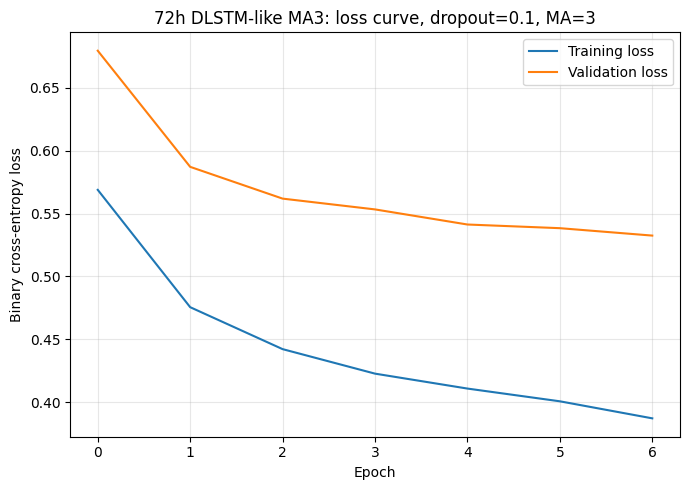

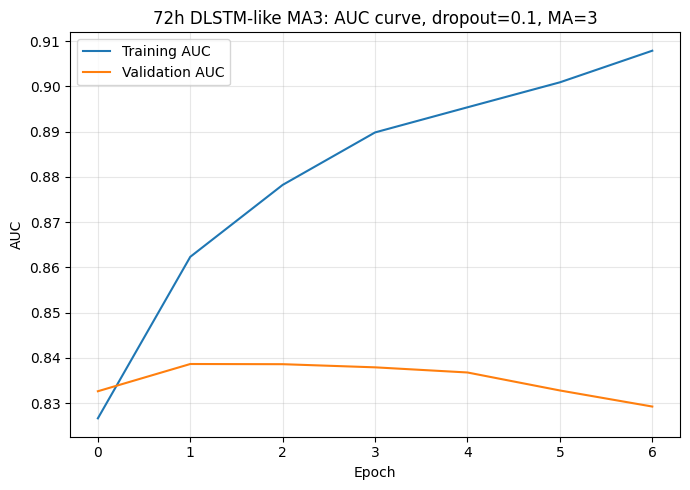

{'Dropout': 0.1, 'Val_TSS_Selected': np.float64(0.5872), 'TSS': np.float64(0.5629), 'HSS': np.float64(0.3087), 'ROC_AUC': np.float64(0.8521), 'PR_AUC': np.float64(0.3899), 'Recall': 0.8054, 'Precision': 0.281, 'F1': 0.4167, 'Best_Val_AUC': 0.8387, 'AUC_Gap_Train_Minus_Val': 0.0237, 'Loss_Gap_Val_Minus_Train': 0.1117, 'Best_Epoch_By_Val_AUC': 2}

72h dropout sensitivity: DLSTM-like MA3, dropout=0.2
Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - auc: 0.8082 - loss: 0.5751 - val_auc: 0.8446 - val_loss: 0.5637
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8642 - loss: 0.4650 - val_auc: 0.8393 - val_loss: 0.5684
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8772 - loss: 0.4428 - val_auc: 0.8413 - val_loss: 0.5560
Epoch 4/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8859 - loss: 0.4289 - val_auc: 0.8419 - val_loss: 0.5440
Epoch 5/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8907 - loss: 0.4188 - val_auc: 0.8406 - val_loss: 0.5389
Epoch 6/25
52/

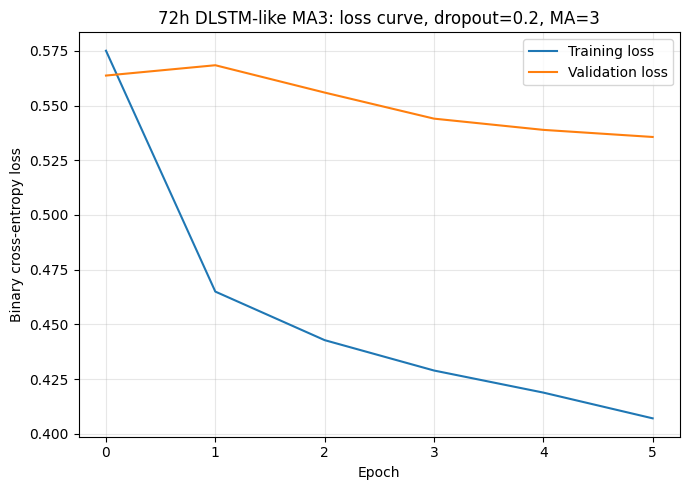

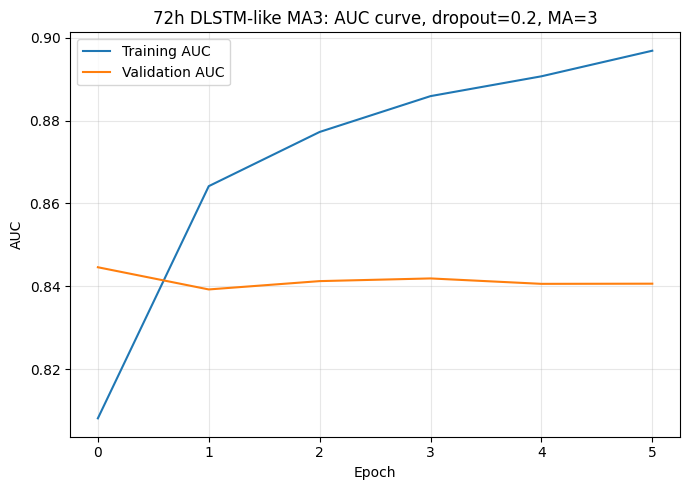

{'Dropout': 0.2, 'Val_TSS_Selected': np.float64(0.5523), 'TSS': np.float64(0.4898), 'HSS': np.float64(0.2924), 'ROC_AUC': np.float64(0.8314), 'PR_AUC': np.float64(0.322), 'Recall': 0.7047, 'Precision': 0.2785, 'F1': 0.3992, 'Best_Val_AUC': 0.8446, 'AUC_Gap_Train_Minus_Val': -0.0364, 'Loss_Gap_Val_Minus_Train': -0.0114, 'Best_Epoch_By_Val_AUC': 1}

72h dropout sensitivity: DLSTM-like MA3, dropout=0.3
Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - auc: 0.7906 - loss: 0.5805 - val_auc: 0.8328 - val_loss: 0.6262
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8541 - loss: 0.4804 - val_auc: 0.8373 - val_loss: 0.5764
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.8726 - loss: 0.4506 - val_auc: 0.8379 - val_loss: 0.5540
Epoch 4/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8808 - loss: 0.4370 - val_auc: 0.8369 - val_loss: 0.5435
Epoch 5/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8876 - loss: 0.4249 - val_auc: 0.8372 - val_loss: 0.5343
Epoch 6/25
5

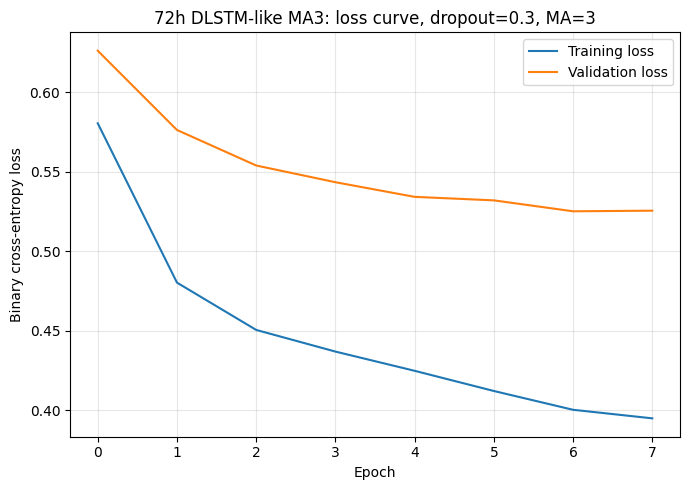

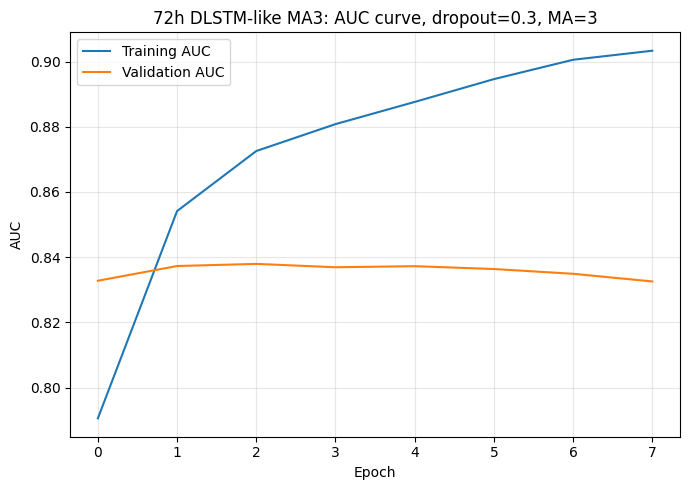

{'Dropout': 0.3, 'Val_TSS_Selected': np.float64(0.5794), 'TSS': np.float64(0.5392), 'HSS': np.float64(0.282), 'ROC_AUC': np.float64(0.8559), 'PR_AUC': np.float64(0.377), 'Recall': 0.8054, 'Precision': 0.2626, 'F1': 0.396, 'Best_Val_AUC': 0.8379, 'AUC_Gap_Train_Minus_Val': 0.0346, 'Loss_Gap_Val_Minus_Train': 0.1034, 'Best_Epoch_By_Val_AUC': 3}

72h dropout sensitivity: DLSTM-like MA3, dropout=0.5
Epoch 1/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - auc: 0.7878 - loss: 0.5887 - val_auc: 0.8405 - val_loss: 0.6105
Epoch 2/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.8507 - loss: 0.4899 - val_auc: 0.8413 - val_loss: 0.5854
Epoch 3/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8634 - loss: 0.4635 - val_auc: 0.8401 - val_loss: 0.5749
Epoch 4/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - auc: 0.8756 - loss: 0.4443 - val_auc: 0.8380 - val_loss: 0.5669
Epoch 5/25
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - auc: 0.8808 - loss: 0.4352 - val_auc: 0.8408 - val_loss: 0.5621
Epoch 6/25
52/52

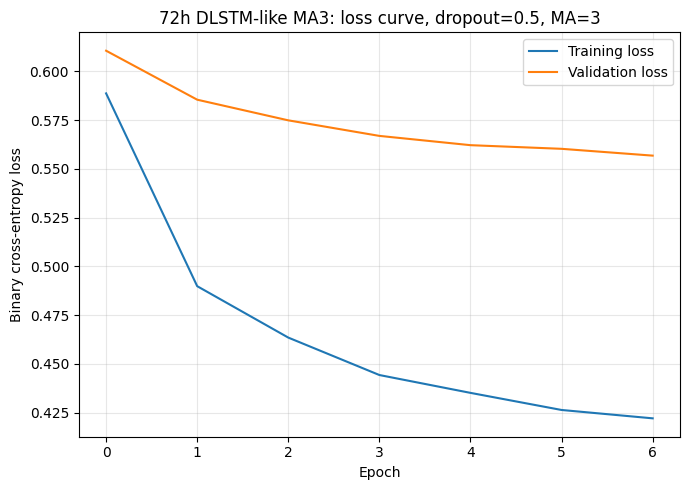

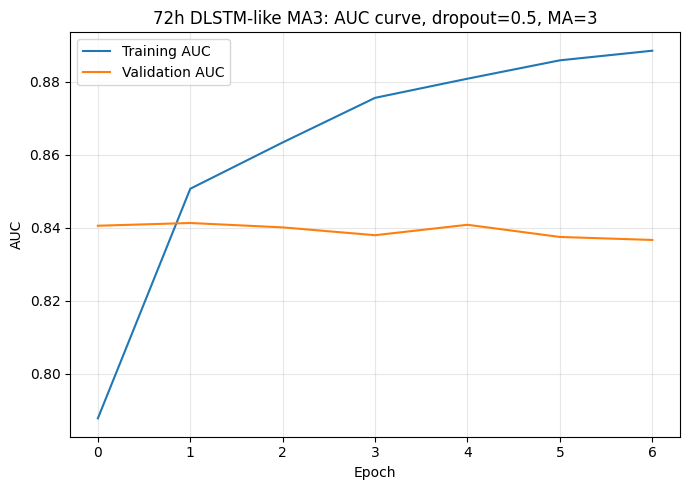

{'Dropout': 0.5, 'Val_TSS_Selected': np.float64(0.5643), 'TSS': np.float64(0.5404), 'HSS': np.float64(0.2875), 'ROC_AUC': np.float64(0.8391), 'PR_AUC': np.float64(0.3742), 'Recall': 0.7987, 'Precision': 0.2668, 'F1': 0.4, 'Best_Val_AUC': 0.8413, 'AUC_Gap_Train_Minus_Val': 0.0094, 'Loss_Gap_Val_Minus_Train': 0.0956, 'Best_Epoch_By_Val_AUC': 2}


,Horizon,Model,Model_Type,MA_Kernel,Dropout,Threshold,Val_TSS_Selected,TSS,HSS,ROC_AUC,...,Epochs_Run,Train_N,Val_N,Test_N,Train_Pos,Val_Pos,Test_Pos,Learning_Curve_CSV,Loss_Curve_PNG,AUC_Curve_PNG
0,72h,DLSTM-like MA3,dlstm,3,0.1,0.63,0.587197,0.562873,0.308747,0.852095,...,7,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...
1,72h,DLSTM-like MA3,dlstm,3,0.2,0.65,0.552287,0.489848,0.292437,0.831435,...,6,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...
2,72h,DLSTM-like MA3,dlstm,3,0.3,0.59,0.579424,0.539176,0.282009,0.855949,...,8,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...
3,72h,DLSTM-like MA3,dlstm,3,0.5,0.63,0.564326,0.540364,0.287528,0.839075,...,7,6607,1416,1415,339,164,149,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...,/content/drive/MyDrive/ASR_MAJOR_REVISION_OVER...



Saved dropout sensitivity results to: /content/drive/MyDrive/ASR_MAJOR_REVISION_OVERFITTING/dropout_sensitivity/dropout_sensitivity_72h.csv


In [42]:
# ============================================================
# ROUND 3B: 72H OVERFITTING + DROPOUT SENSITIVITY
# Representative model: DLSTM-like with MA3
# Paste inside 72h notebook AFTER X_seq, y_seq, t_seq exist
# ============================================================

assert "X_seq" in globals(), "X_seq not found. Run the 72h notebook first."
assert "y_seq" in globals(), "y_seq not found. Run the 72h notebook first."
assert "t_seq" in globals(), "t_seq not found. Run the 72h notebook first."

assert X_seq.shape[1] == 7, f"Expected 72h sequence length 7, got {X_seq.shape[1]}"
assert X_seq.shape[-1] == 32, f"Expected 72h 32 features, got {X_seq.shape[-1]}"

dropout_72h_df = run_dropout_sensitivity(
    X_full=X_seq,
    y_full=y_seq,
    time_full=t_seq,
    horizon="72h",
    model_type="dlstm",
    dropout_values=[0.1, 0.2, 0.3, 0.5],
    ma_kernel=3,
    epochs=25,
    batch_size=128,
    patience=5,
    lr=5e-4,
    units=64,
    dense_units=32,
)